## Biomarker analysis

In [1]:
pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from statsmodels.multivariate.cancorr import CanCorr
from sparsecca import pmd
import seaborn as sns
import pingouin as pg
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import permutation_test_score
from scipy.stats import pearsonr
from impyute.imputation.cs import mice
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import missingno as msno
import miceforest as mf
from sklearn.cross_decomposition import CCA
from sklearn.model_selection import KFold
import itertools

In [3]:
# 데이터셋 경로 path에 추가
path = 'C:/Users/nva_kist/Desktop/minsun/KIST/BioMarker/refined_dataset.xlsx'
df = pd.read_excel(path)

In [4]:
df.head()

,ID,Sex,Age,BMI,AST,ALT,ALP,Bilirubin,Protein,Albumin,...,CD11b.1,HLADR.1,NK.1,NKT1.1,T.1,Transitional B.1,Memory B.1,Early Plasma B .1,Plasma B.1,ABC.1
0,KUMC039,F,66,20.14,40,36,71.0,0.53,7.0,4.6,...,7435.848212,2325.931126,3373.697270,949.023785,69240.336501,642.033790,13.725188,8.235113,79.301086,19.215263
1,KUMC040,M,78,24.54,36,26,75.0,1.32,7.5,4.3,...,12149.508912,7729.607360,3800.419287,1506.942813,109202.890471,39948.855589,159.468308,98.134343,122.667929,482.493855
2,KUMC041,M,47,24.89,22,13,65.0,0.41,6.8,4.6,...,1994.524906,645.388438,9037.154587,719.196158,11731.994607,197.499161,0.000000,5.100972,12.011262,3.378849
3,KUMC042,F,66,25.29,28,16,81.0,0.72,6.8,4.5,...,3316.743565,1284.478895,980.784272,515.782998,43727.047026,526.615437,3.993833,3.993833,21.909028,11.924445
4,KUMC045,M,66,21.59,28,21,51.0,1.10,6.9,4.2,...,4241.189672,1624.390456,2532.864146,2073.689944,57752.264953,4131.331010,46.752821,31.917791,128.570258,123.625248


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 75 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 44 non-null     object 
 1   Sex                44 non-null     object 
 2   Age                44 non-null     int64  
 3   BMI                44 non-null     float64
 4   AST                44 non-null     int64  
 5   ALT                44 non-null     int64  
 6   ALP                43 non-null     float64
 7   Bilirubin          44 non-null     float64
 8   Protein            22 non-null     float64
 9   Albumin            44 non-null     float64
 10  PT                 22 non-null     float64
 11  APTT               22 non-null     float64
 12  Cholesterol        42 non-null     float64
 13  TG                 22 non-null     float64
 14  LDL                22 non-null     float64
 15  HDL                22 non-null     float64
 16  R_Glucose          22 non-nu

In [115]:
df.columns

Index(['ID', 'Sex', 'Age', 'BMI', 'AST', 'ALT', 'ALP', 'Bilirubin', 'Protein',
       'Albumin', 'PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL', 'R_Glucose',
       'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl', 'Amylase',
       'CRP', 'Unnamed: 25', 'B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T',
       'Unnamed: 32', 'NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%', 'Unnamed: 38',
       'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'Unnamed: 43', 'CD20T',
       'Unnamed: 45', 'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm',
       'CD4grzk', 'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Unnamed: 56',
       'Transitional B', 'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC',
       'Unnamed: 62', 'Total', 'B.1', 'CD11b.1', 'HLADR.1', 'NK.1', 'NKT1.1',
       'T.1', 'Transitional B.1', 'Memory B.1', 'Early Plasma B .1',
       'Plasma B.1', 'ABC.1'],
      dtype='object')

In [5]:
cols = ['B',	'CD11b','HLADR','NK','NKT1','T',
        'NKT2',	'MAIT'	,'gd1T','gd2T',	'ConvT%',
'CD8+T','CD4+T','CD8+Treg','CD4+Treg','CD20T','CD4trm','CD8trm','MAITtrm','GD1Ttrm',	
'GD2Ttrm','CD4grzk', 'CD8grzk','MAITgrzK','GD1TgrzK','GD2TgrzK','Transitional B',
'Memory B','Early Plasma B ','Plasma B','ABC'
]

# % 제거하기
df[cols] = (df[cols]
            .replace(r'^\s*$', pd.NA, regex=True) 
            .replace({',': ''}, regex=True)
            .replace({'%': ''}, regex=True)   
            .apply(pd.to_numeric, errors='coerce')
            *100)      

# unnamed 인 column 제거 
df = df.loc[:, ~df.columns.str.contains(r'^Unnamed')]

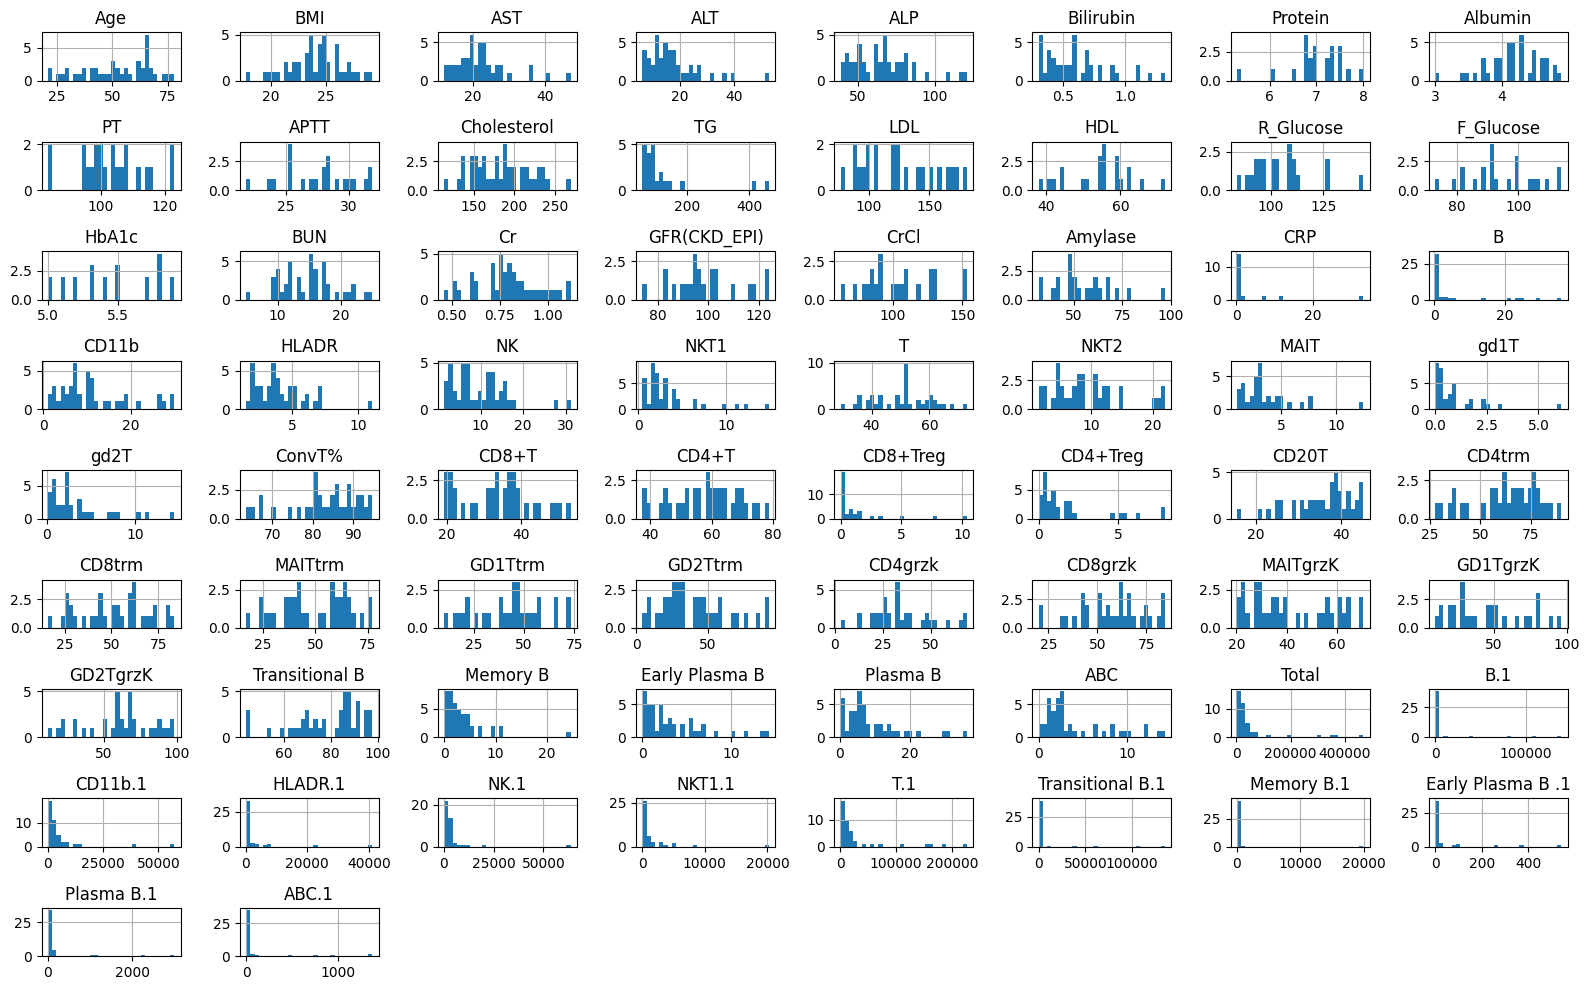

In [8]:
# 데이터 분포 확인
df.hist(bins=30, figsize=(16,10)); plt.tight_layout(); plt.show()

## Task1 - 나이 & 면역세포

 ###  Partial correlation analysis

### pan% & age

In [8]:
columns = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']

for c in columns:
   print('result of age and ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI']))
   print("_________________________________________________")
   

result of age and  B 
           n         r          CI95%     p-val
pearson  44  0.132268  [-0.18, 0.42]  0.397829
_________________________________________________
result of age and  CD11b 
           n         r          CI95%     p-val
pearson  44 -0.253556  [-0.51, 0.05]  0.100876
_________________________________________________
result of age and  HLADR 
           n         r           CI95%     p-val
pearson  44 -0.305647  [-0.56, -0.01]  0.046241
_________________________________________________
result of age and  NK 
           n         r         CI95%     p-val
pearson  44 -0.231679  [-0.5, 0.07]  0.134947
_________________________________________________
result of age and  NKT1 
           n         r          CI95%     p-val
pearson  44 -0.138999  [-0.42, 0.17]  0.374033
_________________________________________________
result of age and  T 
           n         r         CI95%     p-val
pearson  44  0.353325  [0.06, 0.59]  0.020117
______________________________________

#### Change Sex to binary, then set cofounder as sex + BMI

In [53]:
#Sex column 0,1로 바꾸기
df['Sex_01'] = df['Sex'].map({'F': 0, 'M': 1})
print(df['Sex_01'].head())

0    0
1    1
2    1
3    0
4    1
Name: Sex_01, dtype: int64


In [10]:
# BMI + Sex
columns = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']

for c in columns:
   print('result of age and ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI', 'Sex_01']))
   print("_________________________________________________")

result of age and  B 
           n        r          CI95%     p-val
pearson  44  0.10035  [-0.21, 0.39]  0.527183
_________________________________________________
result of age and  CD11b 
           n         r          CI95%     p-val
pearson  44 -0.262178  [-0.52, 0.05]  0.093481
_________________________________________________
result of age and  HLADR 
           n         r           CI95%    p-val
pearson  44 -0.323769  [-0.57, -0.02]  0.03647
_________________________________________________
result of age and  NK 
           n         r          CI95%     p-val
pearson  44 -0.202946  [-0.48, 0.11]  0.197393
_________________________________________________
result of age and  NKT1 
           n         r          CI95%     p-val
pearson  44 -0.120495  [-0.41, 0.19]  0.447189
_________________________________________________
result of age and  T 
           n         r         CI95%     p-val
pearson  44  0.348037  [0.05, 0.59]  0.023908
________________________________________

### T 소분류- NKT2	MAIT	gd1T	gd2T	ConvT% & Age

결측치 처리 

In [ ]:
# 결측치 8명 -> 다중대체법(Multiple Imputation)적용

<Axes: >

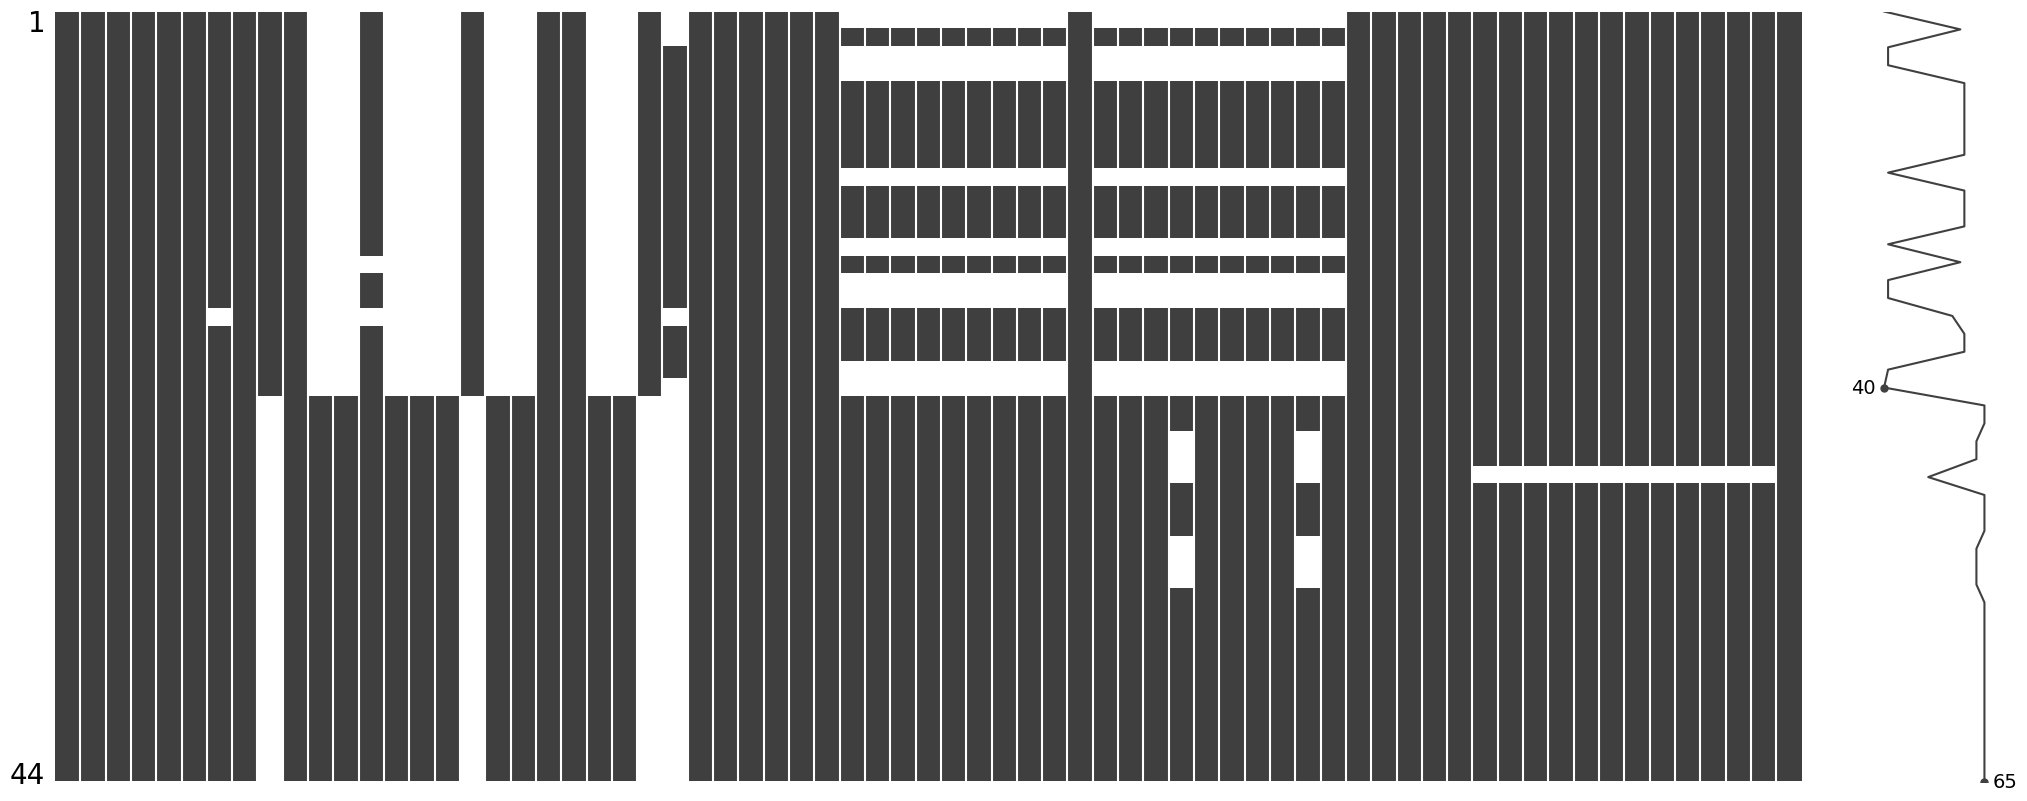

In [ ]:
msno.matrix(df)

### 결측치 처리

1. Multiple Imputation (MICE)

In [17]:
df.columns

Index(['ID', 'Sex', 'Age', 'BMI', 'AST', 'ALT', 'ALP', 'Bilirubin', 'Protein',
       'Albumin', 'PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL', 'R_Glucose',
       'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl', 'Amylase',
       'CRP', 'B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T', 'NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T',
       'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Transitional B',
       'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC', 'Total', 'B.1',
       'CD11b.1', 'HLADR.1', 'NK.1', 'NKT1.1', 'T.1', 'Transitional B.1',
       'Memory B.1', 'Early Plasma B .1', 'Plasma B.1', 'ABC.1', 'Sex_01'],
      dtype='object')

In [54]:
# 최적화된 결측치 처리 방법

impute_cols = ['CRP','ALP','Cholesterol','NKT2','MAIT','gd1T','gd2T','ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T', 'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk', 'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', ]
keep_cols_mice = ['B.1', 'CD11b.1', 'HLADR.1', 'NK.1', 'NKT1.1', 'T.1','Transitional B.1', 
'Memory B.1', 'Early Plasma B .1','Plasma B.1', 'ABC.1']

# 사용 가능한 컬럼만 선택
available_cols_mice = [col for col in keep_cols_mice if col in df.columns]
use_cols_mice = available_cols_mice + impute_cols
df_sub_mice = df[use_cols_mice].copy()

kernel_mice = mf.ImputationKernel(
    data=df_sub_mice,
    num_datasets=5,
    save_all_iterations_data=True,
    random_state=42
)
kernel_mice.mice(iterations=10)

df_mice = df.copy()
df_mice[impute_cols] = kernel_mice.complete_data(dataset=0)[impute_cols]

### T세포 소분류 & Age 사이 Partial correlation anlaysis

In [56]:
# df_mice + BMI
columns = ['NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_mice, x='Age', y= c , covar=['BMI'], method='pearson'))
   print("_________________________________________________")

result of age &  NKT2 
           n         r          CI95%     p-val
pearson  44 -0.359211  [-0.6, -0.07]  0.017998
_________________________________________________
result of age &  MAIT 
           n         r          CI95%    p-val
pearson  44 -0.164601  [-0.44, 0.14]  0.29153
_________________________________________________
result of age &  gd1T 
           n         r          CI95%    p-val
pearson  44 -0.282415  [-0.54, 0.02]  0.06652
_________________________________________________
result of age &  gd2T 
           n         r          CI95%     p-val
pearson  44 -0.226657  [-0.49, 0.08]  0.143852
_________________________________________________
result of age &  ConvT% 
           n         r        CI95%     p-val
pearson  44  0.365427  [0.07, 0.6]  0.015968
_________________________________________________


In [57]:
# df_mice + BMI + Sex
columns = ['NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_mice, x='Age', y= c , covar=['BMI', 'Sex_01' ], method='pearson'))
   print("_________________________________________________")

result of age &  NKT2 
           n         r          CI95%     p-val
pearson  44 -0.358728  [-0.6, -0.06]  0.019653
_________________________________________________
result of age &  MAIT 
           n         r          CI95%     p-val
pearson  44 -0.186312  [-0.46, 0.12]  0.237451
_________________________________________________
result of age &  gd1T 
           n         r          CI95%     p-val
pearson  44 -0.279663  [-0.54, 0.03]  0.072859
_________________________________________________
result of age &  gd2T 
           n         r         CI95%    p-val
pearson  44 -0.231282  [-0.5, 0.08]  0.14056
_________________________________________________
result of age &  ConvT% 
           n         r         CI95%     p-val
pearson  44  0.378177  [0.08, 0.61]  0.013535
_________________________________________________


### ConvT & Age partial correlation analysis

In [ ]:
df_mice['CD8+T'].isna().sum()

np.int64(0)

In [67]:
# df_mice - BMI
columns = ['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg']
print('통제 변수 : BMI')
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_mice, x='Age', y= c , covar=['BMI'], method='pearson'))
   print("_________________________________________________")

통제 변수 : BMI
result of age &  CD8+T 
           n         r          CI95%     p-val
pearson  44  0.183574  [-0.12, 0.46]  0.238658
_________________________________________________
result of age &  CD4+T 
           n         r          CI95%     p-val
pearson  44 -0.159279  [-0.44, 0.15]  0.307625
_________________________________________________
result of age &  CD8+Treg 
           n         r          CI95%     p-val
pearson  44  0.138474  [-0.17, 0.42]  0.375858
_________________________________________________
result of age &  CD4+Treg 
           n         r        CI95%     p-val
pearson  44  0.108778  [-0.2, 0.4]  0.487461
_________________________________________________


In [68]:
# df_mice - BMI
print('통제 변수 : BMI + 성별')
columns = ['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_mice, x='Age', y= c , covar=['BMI', 'Sex_01'], method='pearson'))
   print("_________________________________________________")

통제 변수 : BMI + 성별
result of age &  CD8+T 
           n         r         CI95%     p-val
pearson  44  0.214781  [-0.1, 0.49]  0.171959
_________________________________________________
result of age &  CD4+T 
           n         r          CI95%     p-val
pearson  44 -0.185952  [-0.46, 0.13]  0.238375
_________________________________________________
result of age &  CD8+Treg 
           n         r          CI95%     p-val
pearson  44  0.124144  [-0.19, 0.41]  0.433448
_________________________________________________
result of age &  CD4+Treg 
           n         r          CI95%     p-val
pearson  44  0.098108  [-0.21, 0.39]  0.536498
_________________________________________________


### CD20T & age partial correlation analysis

In [69]:
columns = ['CD20T']
for c in columns:
   print('통제 변수 : BMI ')
   print('result of age & ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI'], method='pearson'))
   print("_________________________________________________")
   print('통제 변수 : BMI + 성별')
   print('result of age & ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI', 'Sex_01'], method='pearson'))
   print("_________________________________________________")

통제 변수 : BMI 
result of age &  CD20T 
           n         r          CI95%     p-val
pearson  44  0.220541  [-0.09, 0.49]  0.155277
_________________________________________________
통제 변수 : BMI + 성별
result of age &  CD20T 
           n         r         CI95%     p-val
pearson  44  0.233192  [-0.08, 0.5]  0.137219
_________________________________________________


### B cell 소분류 & age partial correlation analysis

In [71]:
# covar = BMI
print('통제 변수 : BMI')
columns = ['Transitional B', 'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI'], method='pearson'))
   print("_________________________________________________")

통제 변수 : BMI
result of age &  Transitional B 
           n         r         CI95%     p-val
pearson  44 -0.202703  [-0.47, 0.1]  0.192361
_________________________________________________
result of age &  Memory B 
           n         r          CI95%     p-val
pearson  44  0.062199  [-0.24, 0.36]  0.691935
_________________________________________________
result of age &  Early Plasma B  
           n         r        CI95%     p-val
pearson  44  0.107399  [-0.2, 0.4]  0.493031
_________________________________________________
result of age &  Plasma B 
           n         r          CI95%     p-val
pearson  44  0.266983  [-0.04, 0.53]  0.083504
_________________________________________________
result of age &  ABC 
           n         r          CI95%     p-val
pearson  44  0.021281  [-0.28, 0.32]  0.892256
_________________________________________________


In [73]:
# covar = BMI+ Sex
print('통제 변수 : BMI + 성별')
columns = ['Transitional B', 'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI', 'Sex_01'], method='pearson'))
   print("_________________________________________________")

통제 변수 : BMI + 성별
result of age &  Transitional B 
           n         r          CI95%     p-val
pearson  44 -0.179929  [-0.46, 0.13]  0.254197
_________________________________________________
result of age &  Memory B 
           n         r          CI95%     p-val
pearson  44  0.020742  [-0.28, 0.32]  0.896267
_________________________________________________
result of age &  Early Plasma B  
           n         r          CI95%     p-val
pearson  44  0.119836  [-0.19, 0.41]  0.449696
_________________________________________________
result of age &  Plasma B 
           n         r          CI95%     p-val
pearson  44  0.242818  [-0.07, 0.51]  0.121275
_________________________________________________
result of age &  ABC 
           n         r          CI95%   p-val
pearson  44  0.025732  [-0.28, 0.33]  0.8715
_________________________________________________


### ConvT소분류 & age

#### 결측치 삭제

In [36]:
# covar = BMI
columns = ['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df, x='Age', y= c , covar=['BMI'], method='pearson'))
   print("_________________________________________________")

result of age &  CD8+T 
           n         r          CI95%    p-val
pearson  35  0.138351  [-0.21, 0.46]  0.43521
_________________________________________________
result of age &  CD4+T 
           n         r          CI95%     p-val
pearson  35 -0.126055  [-0.45, 0.22]  0.477474
_________________________________________________
result of age &  CD8+Treg 
           n         r         CI95%     p-val
pearson  35  0.192483  [-0.16, 0.5]  0.275441
_________________________________________________
result of age &  CD4+Treg 
           n         r         CI95%     p-val
pearson  35  0.149662  [-0.2, 0.46]  0.398219
_________________________________________________


##### MICE로 다중대체

In [ ]:
# covar = BMI
columns = ['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_mice, x='Age', y= c , covar=['BMI'], method='pearson'))
   print("_________________________________________________")

result of age &  CD8+T 
           n         r         CI95%    p-val
pearson  44  0.202895  [-0.1, 0.47]  0.19193
_________________________________________________
result of age &  CD4+T 
           n         r          CI95%     p-val
pearson  44 -0.214379  [-0.48, 0.09]  0.167445
_________________________________________________
result of age &  CD8+Treg 
           n         r          CI95%     p-val
pearson  44  0.159944  [-0.15, 0.44]  0.305584
_________________________________________________
result of age &  CD4+Treg 
           n         r         CI95%     p-val
pearson  44  0.101661  [-0.2, 0.39]  0.516547
_________________________________________________


In [ ]:
# covar = BMI+ Sex
columns = ['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_mice, x='Age', y= c , covar=['BMI', 'Sex_01'], method='pearson'))
   print("_________________________________________________")

result of age &  CD8+T 
           n         r         CI95%     p-val
pearson  44  0.236953  [-0.07, 0.5]  0.130815
_________________________________________________
result of age &  CD4+T 
           n         r         CI95%     p-val
pearson  44 -0.236099  [-0.5, 0.07]  0.132249
_________________________________________________
result of age &  CD8+Treg 
           n         r          CI95%     p-val
pearson  44  0.132587  [-0.18, 0.42]  0.402571
_________________________________________________
result of age &  CD4+Treg 
           n         r          CI95%     p-val
pearson  44  0.091283  [-0.22, 0.38]  0.565337
_________________________________________________


### T Subset & age

In [77]:
# covar = BMI+ Sex

columns = ['CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK']
print('통제 변수 : BMI + 성별')
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_mice, x='Age', y= c , covar=['BMI', 'Sex_01'], method='pearson'))
   print("_________________________________________________")

통제 변수 : BMI + 성별
result of age &  CD4trm 
           n         r          CI95%     p-val
pearson  44 -0.189876  [-0.47, 0.12]  0.228437
_________________________________________________
result of age &  CD8trm 
           n         r          CI95%     p-val
pearson  44 -0.182686  [-0.46, 0.13]  0.246868
_________________________________________________
result of age &  MAITtrm 
           n         r          CI95%     p-val
pearson  44 -0.127515  [-0.42, 0.18]  0.420966
_________________________________________________
result of age &  GD1Ttrm 
           n         r         CI95%     p-val
pearson  44  0.003906  [-0.3, 0.31]  0.980413
_________________________________________________
result of age &  GD2Ttrm 
           n         r        CI95%     p-val
pearson  44 -0.001014  [-0.3, 0.3]  0.994916
_________________________________________________
result of age &  CD4grzk 
           n         r          CI95%     p-val
pearson  44 -0.171846  [-0.45, 0.14]  0.276508
_______________

## Partial Least Sqaures regression 함수 사용해서 나이& 면역세포 관계 파악 

##### 함수

In [ ]:
def run_plsr(
    X,
    y,
    n_components=1,
    x_cols=None,
    scale=True,
    verbose=True,
    do_permutation=True,
    n_permutations=1000,
    cv_splits=5,
    random_state=42,
):

    if hasattr(X, "values"):
        if x_cols is None:
            x_cols = list(X.columns)
        X_mat = X.values
    else:
        X_mat = np.asarray(X)
        if x_cols is None:
            x_cols = [f"X{i+1}" for i in range(X_mat.shape[1])]

    # y를 2D로 맞추기
    if hasattr(y, "values"):
        y_mat = np.asarray(y).reshape(-1, 1) if y.ndim == 1 else y.values
    else:
        y_arr = np.asarray(y)
        y_mat = y_arr.reshape(-1, 1) if y_arr.ndim == 1 else y_arr

    # 스케일링
    if scale:
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_scaled = scaler_X.fit_transform(X_mat)
        y_scaled = scaler_y.fit_transform(y_mat)
    else:
        X_scaled = X_mat
        y_scaled = y_mat

    # PLS 적합
    pls = PLSRegression(n_components=n_components)
    pls.fit(X_scaled, y_scaled)

    # 예측 및 상관계수
    y_pred = pls.predict(X_scaled)
    r, p = pearsonr(y_scaled[:, 0], y_pred[:, 0])

    # Weights만 확인
    weights = pd.Series(pls.x_weights_[:, 0], index=x_cols).sort_values(key=abs, ascending=False)

    if verbose:
        print(f"PLSR Component 1과 y의 correlation: {r:.4f} (p={p:.4f})")
        print("\n=== PLSR Weights ===")
        print(weights)

    # Permutation test
    perm_p = None
    cv_score = None
    if do_permutation:
        try:
            pls_perm = PLSRegression(n_components=n_components)
            cv_score, perm_scores, perm_p = permutation_test_score(
                pls_perm,
                X_scaled,
                y_scaled.ravel(),
                scoring="r2",
                n_permutations=n_permutations,
                cv=cv_splits,
                random_state=random_state,
            )
            if verbose:
                print(f"\nPermutation test (R2) -> CV R2: {cv_score:.4f}, p_perm: {perm_p:.4f}")
        except Exception as e:
            if verbose:
                print(f"Permutation test failed: {e}")

    results = {
        "pls": pls,
        "r": r,
        "p": p,
        "weights": weights,
        "y_true_scaled": y_scaled[:, 0],
        "y_pred_scaled": y_pred[:, 0],
        "perm_p": perm_p,
        "cv_r2": cv_score,
    }

    return results

##### 함수 사용

In [79]:
X = df[['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']]
y = df['Age']
print('Age & PAN%')
plsr_results = run_plsr(X, y, n_components=1)

Age & PAN%
PLSR Component 1과 y의 correlation: 0.4104 (p=0.0057)

=== PLSR Weights ===
T        0.566622
HLADR   -0.508744
CD11b   -0.403101
NK      -0.388593
NKT1    -0.234467
B        0.227266
dtype: float64

Permutation test (R2) -> CV R2: -0.2355, p_perm: 0.2557


In [80]:
X = df_mice[['NKT2', 'MAIT', 'gd1T','gd2T', 'ConvT%']]
y = df_mice['Age']
print('Age & T%')
plsr_results = run_plsr(X, y, n_components=1)

Age & T%
PLSR Component 1과 y의 correlation: 0.4023 (p=0.0068)

=== PLSR Weights ===
ConvT%    0.563596
NKT2     -0.561696
gd1T     -0.443318
gd2T     -0.348419
MAIT     -0.221200
dtype: float64

Permutation test (R2) -> CV R2: -0.1825, p_perm: 0.2288


In [81]:
X = df_mice[['CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK']]
y = df_mice['Age']
print('Age & Tsubset%')
plsr_results = run_plsr(X, y, n_components=1)

Age & Tsubset%
PLSR Component 1과 y의 correlation: 0.2535 (p=0.0968)

=== PLSR Weights ===
CD8trm      0.442387
MAITgrzK   -0.440820
CD4grzk     0.413419
CD4trm      0.404325
MAITtrm     0.378411
CD8grzk     0.303989
GD2TgrzK   -0.177135
GD1TgrzK    0.090996
GD2Ttrm     0.017717
GD1Ttrm     0.001465
dtype: float64

Permutation test (R2) -> CV R2: -0.4870, p_perm: 0.6434


In [82]:
X = df_mice[['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg']]
y = df_mice['Age']
print('Age & ConvT%')
plsr_results = run_plsr(X, y, n_components=1)

Age & ConvT%
PLSR Component 1과 y의 correlation: 0.2107 (p=0.1697)

=== PLSR Weights ===
CD8+T       0.592619
CD4+T      -0.526102
CD8+Treg    0.477384
CD4+Treg    0.379637
dtype: float64

Permutation test (R2) -> CV R2: -0.5220, p_perm: 0.8012


In [83]:
X = df_mice[['Transitional B','Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']]
y = df_mice['Age']
print('Age & B%')
plsr_results = run_plsr(X, y, n_components=1)

Age & B%
PLSR Component 1과 y의 correlation: 0.2171 (p=0.1568)

=== PLSR Weights ===
Plasma B           0.722950
Transitional B    -0.577380
Early Plasma B     0.324479
Memory B           0.187621
ABC                0.059051
dtype: float64

Permutation test (R2) -> CV R2: -0.4327, p_perm: 0.6943


# Task2 - 간,신장,대사 & 면역세포 바이오마커 분석

In [2]:
df.columns

Index(['ID', 'Sex', 'Age', 'BMI', 'AST', 'ALT', 'ALP', 'Bilirubin', 'Protein',
       'Albumin', 'PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL', 'R_Glucose',
       'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl', 'Amylase',
       'CRP', 'Unnamed: 25', 'B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T',
       'Unnamed: 32', 'NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%', 'Unnamed: 38',
       'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'Unnamed: 43', 'CD20T',
       'Unnamed: 45', 'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm',
       'CD4grzk', 'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Unnamed: 56',
       'Transitional B', 'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC',
       'Unnamed: 62', 'Total', 'B.1', 'CD11b.1', 'HLADR.1', 'NK.1', 'NKT1.1',
       'T.1', 'Transitional B.1', 'Memory B.1', 'Early Plasma B .1',
       'Plasma B.1', 'ABC.1'],
      dtype='object')

In [6]:
# 각각 간, 신장 면역세포 -> 22명씩 나누기
df1 = df_mice.iloc[:22]
df2 = df_mice.iloc[22:]
print(df1.shape, df2.shape)

(22, 68) (22, 68)


## df1

### CCA

cca할때는 간,신장,대사 나눠서 면역세포랑 관련성 보기

##### CCA 함수

In [ ]:
def run_cca_perm(
    df,
    X_cols,
    Z_cols,
    n_components=1,
    standardize=True,
    B=1000,
    random_state=0,
    abs_test=True, 
    plus_one_correction=True,  
    verbose=True
):
    # 0) 컬럼 체크
    miss_X = [c for c in X_cols if c not in df.columns]
    miss_Z = [c for c in Z_cols if c not in df.columns]
    if miss_X or miss_Z:
        raise ValueError(f"Missing columns -> X: {miss_X}, Z: {miss_Z}")

    # 1) X, Z 추출
    X = df[X_cols].to_numpy(dtype=float)
    Z = df[Z_cols].to_numpy(dtype=float)

    # 결측치 체크
    if np.isnan(X).any() or np.isnan(Z).any():
        raise ValueError("X 또는 Z에 NaN이 있습니다. imputation 후 실행하세요.")

    # 2) 표준화
    scaler_X, scaler_Z = None, None
    if standardize:
        scaler_X = StandardScaler()
        scaler_Z = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
        Z_scaled = scaler_Z.fit_transform(Z)
    else:
        X_scaled, Z_scaled = X, Z

    # 3) 관측 상관(r_obs)
    def cca_statistic(X_in, Z_in):
        cca_tmp = CCA(n_components=n_components)
        U_tmp, V_tmp = cca_tmp.fit_transform(X_in, Z_in)
        return pearsonr(U_tmp[:, 0], V_tmp[:, 0])[0]  # comp1 corr

    r_obs = cca_statistic(X_scaled, Z_scaled)

    # 4) permutation
    rng = np.random.default_rng(random_state)
    r_perm = np.empty(B, dtype=float)

    for i in range(B):
        idx = rng.permutation(X_scaled.shape[0])
        X_perm = X_scaled[idx, :]
        r_perm[i] = cca_statistic(X_perm, Z_scaled)

    if abs_test:
        hits = np.sum(np.abs(r_perm) >= np.abs(r_obs))
    else:
        hits = np.sum(r_perm >= r_obs)

    if plus_one_correction:
        p_perm = (hits + 1) / (B + 1)
    else:
        p_perm = hits / B

    # 5) 최종 CCA fit
    cca = CCA(n_components=n_components)
    U, V = cca.fit_transform(X_scaled, Z_scaled)

    wX = pd.Series(cca.x_weights_[:, 0], index=X_cols).sort_values(key=np.abs, ascending=False)
    wZ = pd.Series(cca.y_weights_[:, 0], index=Z_cols).sort_values(key=np.abs, ascending=False)

    if verbose:
        print("\n=== CCA + Permutation Test ===")
        print(f"n_components = {n_components}")
        print(f"Observed correlation (comp1): {r_obs:.6f}")
        print(f"Permutation p-value: {p_perm:.6f}  (B={B}, abs_test={abs_test})")

        print("\n[X weights]")
        print(wX)

        print("\n[Z weights]")
        print(wZ)

    return {
        "cca": cca,
        "U": U,
        "V": V,
        "r_obs": r_obs,
        "r_perm": r_perm,
        "p_perm": p_perm,
        "wX": wX,
        "wZ": wZ,
        "X_cols": X_cols,
        "Z_cols": Z_cols,
        "scaler_X": scaler_X,
        "scaler_Z": scaler_Z,
    }


##### 함수 사용

In [15]:
# 간 vs 전체 면역세포
X_cols = ['AST','ALT','ALP','Bilirubin','Protein','Albumin']
Z_cols = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T', 'NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T',
       'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Transitional B',
       'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']

res = run_cca_perm(
    df=df1,
    X_cols=X_cols,
    Z_cols=Z_cols,
    n_components=1,
    standardize=True,
    B=1000,
    random_state=0,
    abs_test=True,
    plus_one_correction=True,
    verbose=True
)


=== CCA + Permutation Test ===
n_components = 1
Observed correlation (comp1): 1.000000
Permutation p-value: 0.848152  (B=1000, abs_test=True)

[X weights]
Protein      0.828747
Albumin     -0.543520
Bilirubin   -0.094625
AST         -0.066228
ALP          0.065804
ALT         -0.009672
dtype: float64

[Z weights]
GD1TgrzK           0.327827
CD8+T              0.320208
GD2TgrzK           0.314614
gd1T               0.307110
GD2Ttrm           -0.285117
B                  0.273045
CD11b              0.259744
MAITgrzK          -0.256652
T                  0.235230
ABC               -0.228605
ConvT%            -0.210727
CD4grzk            0.154400
CD8+Treg          -0.152624
Memory B           0.151472
HLADR              0.140448
MAIT              -0.125604
CD8trm             0.099698
CD20T              0.095767
CD8grzk           -0.093228
Early Plasma B     0.088152
GD1Ttrm           -0.066673
Plasma B          -0.053515
MAITtrm           -0.048229
CD4+Treg           0.039068
NKT1        

In [16]:
# 신장  vs 전체 면역세포
X_cols = ['BUN', 'Cr']
Z_cols = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T', 'NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T',
       'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Transitional B',
       'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']

res = run_cca_perm(
    df=df1,
    X_cols=X_cols,
    Z_cols=Z_cols,
    n_components=1,
    standardize=True,
    B=1000,
    random_state=0,
    abs_test=True,
    plus_one_correction=True,
    verbose=True
)


=== CCA + Permutation Test ===
n_components = 1
Observed correlation (comp1): 1.000000
Permutation p-value: 0.625375  (B=1000, abs_test=True)

[X weights]
Cr     0.979453
BUN    0.201674
dtype: float64

[Z weights]
GD1TgrzK          -0.394878
NKT1               0.370066
MAIT               0.329823
gd1T              -0.310470
MAITtrm            0.305516
ABC               -0.264926
Early Plasma B    -0.195727
GD2TgrzK           0.178378
CD20T              0.175855
CD11b              0.156457
CD4trm            -0.156022
Memory B          -0.149680
CD8grzk           -0.148672
MAITgrzK          -0.143956
B                  0.136540
NKT2              -0.122582
CD4grzk            0.118904
ConvT%             0.110270
HLADR             -0.109351
Transitional B     0.103415
GD1Ttrm           -0.101730
NK                 0.089467
gd2T              -0.077388
T                  0.069945
CD8trm             0.058361
GD2Ttrm           -0.054417
Plasma B           0.044068
CD4+T              0.034862


In [17]:
# 대사  vs 전체 면역세포
X_cols = ['Cholesterol', 'R_Glucose', 'Amylase', 'CRP']
Z_cols = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T', 'NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T',
       'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Transitional B',
       'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']

res = run_cca_perm(
    df=df1,
    X_cols=X_cols,
    Z_cols=Z_cols,
    n_components=1,
    standardize=True,
    B=1000,
    random_state=0,
    abs_test=True,
    plus_one_correction=True,
    verbose=True
)


=== CCA + Permutation Test ===
n_components = 1
Observed correlation (comp1): 1.000000
Permutation p-value: 0.637363  (B=1000, abs_test=True)

[X weights]
Amylase        0.949252
CRP            0.252348
R_Glucose     -0.161623
Cholesterol    0.095492
dtype: float64

[Z weights]
gd1T              -0.348991
ABC               -0.318875
GD1TgrzK          -0.311101
CD8+Treg           0.299952
MAITgrzK          -0.264475
NKT1               0.264317
Memory B          -0.248884
gd2T               0.242855
CD4trm             0.229688
CD4grzk            0.226723
CD11b              0.164120
GD2TgrzK           0.159419
CD8grzk            0.156185
B                 -0.146975
MAITtrm           -0.145902
CD8+T             -0.133082
NK                -0.109812
CD4+T             -0.108738
CD8trm            -0.103957
Plasma B           0.095990
Transitional B     0.081194
CD20T              0.080077
HLADR              0.079825
MAIT              -0.076720
ConvT%             0.071376
T                 -0

### Sparse CCA

##### Sparse cca 함수

In [ ]:
def apply_sparse_cca(X, Z, X_cols=None, Z_cols=None, 
                     standardize=True, 
                     find_best_n=True,
                     find_best_penalty=True,
                     penalty_range=None,
                     n_components=None,
                     penaltyu=None,
                     penaltyv=None,
                     n_splits=5,
                     random_state=42,
                     do_permutation_test=True,
                     n_permutations=1000,
                     visualize=True,
                     verbose=True):
    
    # 데이터 준비
    if isinstance(X, pd.DataFrame):
        X = X.values
    if isinstance(Z, pd.DataFrame):
        Z = Z.values
    
    # 표준화
    if standardize:
        X = ((X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12))
        Z = ((Z - Z.mean(axis=0)) / (Z.std(axis=0) + 1e-12))
    
    # 1. 최적 컴포넌트 수 결정
    if find_best_n:
        if verbose:
            print("=" * 50)
            print("Finding optimal number of components...")
            print("=" * 50)
        
        # max_k = min(X.shape[1], Z.shape[1], X.shape[0]-1)
        
        max_k = 2  # 표본이 제한적이기 때문에 2로 설정 
        cca = CCA(n_components=max_k)
        U_cca, V_cca = cca.fit_transform(X, Z)
        
        cors = []
        for i in range(max_k):
            r = np.corrcoef(U_cca[:, i], V_cca[:, i])[0, 1]
            cors.append(r)
            if verbose:
                print(f"Component {i+1}: correlation = {r:.4f}")
        
        # 급격히 떨어지는 지점 찾기
        best_n = 1
        for i in range(len(cors)-1):
            if cors[i] - cors[i+1] > 0.1:
                best_n = i + 1
                break
        else:
            best_n = len([c for c in cors if c > 0.1])
        
        if verbose:
            print(f"\nRecommended n_components: {best_n}\n")
    else:
        if n_components is None:
            raise ValueError("n_components must be specified when find_best_n=False")
        best_n = n_components
    
    # 2. 최적 penalty 파라미터 찾기
    if find_best_penalty:
        if verbose:
            print("=" * 50)
            print("Grid search for best penalty parameters...")
            print("=" * 50)
        
        if penalty_range is None:
            penalty_range = np.arange(0.1, 1.0, 0.1)
        
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        best_score = -np.inf
        best_penaltyu = None
        best_penaltyv = None
        results_grid = []
        
        for penaltyu, penaltyv in itertools.product(penalty_range, penalty_range):
            cv_scores = []
            
            for train_idx, val_idx in kf.split(X):
                X_train, X_val = X[train_idx], X[val_idx]
                Z_train, Z_val = Z[train_idx], Z[val_idx]
                
                try:
                    U, V, D = pmd(X_train.T @ Z_train, K=best_n,
                                 penaltyu=penaltyu, penaltyv=penaltyv,
                                 standardize=False)
                    
                    X_scores = X_val @ U[:, :best_n]
                    Z_scores = Z_val @ V[:, :best_n]
                    
                    corrs = []
                    for k in range(best_n):
                        rk = np.corrcoef(X_scores[:, k], Z_scores[:, k])[0, 1]
                        if not np.isnan(rk):
                            corrs.append(rk)
                    
                    if len(corrs) > 0:
                        cv_scores.append(np.mean(corrs))
                except:
                    continue
            
            if len(cv_scores) > 0:
                mean_score = np.mean(cv_scores)
                results_grid.append((penaltyu, penaltyv, mean_score))
                
                if mean_score > best_score:
                    best_score = mean_score
                    best_penaltyu = penaltyu
                    best_penaltyv = penaltyv
        
        if verbose:
            print(f"Best penaltyu: {best_penaltyu:.3f}")
            print(f"Best penaltyv: {best_penaltyv:.3f}")
            print(f"Best CV score: {best_score:.4f}\n")
    else:
        if penaltyu is None or penaltyv is None:
            raise ValueError("penaltyu and penaltyv must be specified when find_best_penalty=False")
        best_penaltyu = penaltyu
        best_penaltyv = penaltyv
    
    # 3. 전체 데이터에 Sparse CCA 적용
    if verbose:
        print("=" * 50)
        print("Applying Sparse CCA with best parameters...")
        print(f"penaltyu = {best_penaltyu:.3f}, penaltyv = {best_penaltyv:.3f}, n_components = {best_n}")
        print("=" * 50)
    
    U, V, D = pmd(X.T @ Z, K=best_n,
                 penaltyu=best_penaltyu,
                 penaltyv=best_penaltyv,
                 standardize=False)
    
    X_scores = X @ U[:, :best_n]
    Z_scores = Z @ V[:, :best_n]
    
    # 각 컴포넌트의 canonical correlation 계산
    sparse_cors = []
    for k in range(best_n):
        rk = np.corrcoef(X_scores[:, k], Z_scores[:, k])[0, 1]
        sparse_cors.append(rk)
        if verbose:
            print(f"Sparse CCA Component {k+1}: correlation = {rk:.4f}")
    
    if verbose:
        print(f"\nAverage correlation: {np.mean(sparse_cors):.4f}\n")
    
    # 4. Weights 확인
    if X_cols is None:
        X_cols = [f'X_{i}' for i in range(X.shape[1])]
    if Z_cols is None:
        Z_cols = [f'Z_{i}' for i in range(Z.shape[1])]
    
    X_weights_dict = {}
    Z_weights_dict = {}
    
    for k in range(best_n):
        x_weights = pd.Series(U[:, k], index=X_cols)
        z_weights = pd.Series(V[:, k], index=Z_cols)
        
        if verbose:
            print(f"=== Component {k+1} ===")
            print("\nX Weights:")
            print(x_weights.sort_values(key=abs, ascending=False))
            print(f"Non-zero weights: {(x_weights != 0).sum()} / {len(x_weights)}")
            print("\nZ Weights:")
            print(z_weights.sort_values(key=abs, ascending=False))
            print(f"Non-zero weights: {(z_weights != 0).sum()} / {len(z_weights)}\n")
        
        X_weights_dict[f'Component_{k+1}'] = x_weights
        Z_weights_dict[f'Component_{k+1}'] = z_weights
    
    # 5. 시각화
    if visualize:
        fig, axes = plt.subplots(1, best_n, figsize=(6*best_n, 5))
        if best_n == 1:
            axes = [axes]
        
        for k in range(best_n):
            axes[k].scatter(X_scores[:, k], Z_scores[:, k], alpha=0.6)
            axes[k].set_xlabel(f'X Canonical Score (Component {k+1})')
            axes[k].set_ylabel(f'Z Canonical Score (Component {k+1})')
            axes[k].set_title(f'Component {k+1}: r = {sparse_cors[k]:.4f}')
            axes[k].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    # 6. Permutation Test
    permutation_pvalue = None
    if do_permutation_test:
        if verbose:
            print("\n" + "=" * 50)
            print("Permutation Test for Statistical Significance")
            print("=" * 50)
        
        def sparse_cca_statistic(X, Z, penaltyu, penaltyv, n_components):
            """Sparse CCA를 수행하고 canonical correlation의 합을 반환"""
            try:
                U, V, D = pmd(X.T @ Z, K=n_components,
                             penaltyu=penaltyu, penaltyv=penaltyv, standardize=False)
                
                X_scores = X @ U[:, :n_components]
                Z_scores = Z @ V[:, :n_components]
                
                corrs = []
                for k in range(n_components):
                    rk = np.corrcoef(X_scores[:, k], Z_scores[:, k])[0, 1]
                    if not np.isnan(rk):
                        corrs.append(rk)
                
                stat = np.sum(np.array(corrs)**2) if len(corrs) > 0 else 0.0
                return stat
            except:
                return 0.0
        
        r_obs = sparse_cca_statistic(X, Z, best_penaltyu, best_penaltyv, best_n)
        if verbose:
            print(f"Observed statistic (sum of squared correlations): {r_obs:.6f}")
            print(f"Running {n_permutations} permutations...")
        
        rng = np.random.default_rng(random_state)
        r_perm = []
        
        for i in range(n_permutations):
            idx = rng.permutation(X.shape[0])
            X_perm = X[idx, :]
            r_perm.append(sparse_cca_statistic(X_perm, Z, best_penaltyu, best_penaltyv, best_n))
            
            if verbose and (i + 1) % 100 == 0:
                print(f"  Completed {i+1}/{n_permutations} permutations...")
        
        r_perm = np.array(r_perm)
        # permutation_pvalue = np.mean(r_perm >= r_obs)
        permutation_pvalue = (np.sum(r_perm >= r_obs) + 1) / (n_permutations + 1)
        
        if verbose:
            print(f"\nPermutation p-value: {permutation_pvalue:.4f}")
            print(f"95% percentile of permuted statistics: {np.percentile(r_perm, 95):.6f}")
            print(f"99% percentile of permuted statistics: {np.percentile(r_perm, 99):.6f}")
        
        if visualize:
            plt.figure(figsize=(10, 6))
            plt.hist(r_perm, bins=50, alpha=0.7, edgecolor='black', label='Permuted statistics')
            plt.axvline(r_obs, color='red', linestyle='--', linewidth=2, label=f'Observed ({r_obs:.4f})')
            plt.axvline(np.percentile(r_perm, 95), color='orange', linestyle=':', linewidth=2, label='95th percentile')
            plt.xlabel('Test Statistic (Sum of Squared Correlations)')
            plt.ylabel('Frequency')
            plt.title(f'Permutation Test Distribution\np-value = {permutation_pvalue:.4f}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
    
    # 결과 반환
    results = {
        'best_n': best_n,
        'best_penaltyu': best_penaltyu,
        'best_penaltyv': best_penaltyv,
        'correlations': sparse_cors,
        'X_weights': X_weights_dict,
        'Z_weights': Z_weights_dict,
        'X_scores': X_scores,
        'Z_scores': Z_scores,
        'permutation_pvalue': permutation_pvalue
    }
    
    return results

##### scca 함수 사용

Finding optimal number of components...
Component 1: correlation = 0.9773
Component 2: correlation = 0.9319

Recommended n_components: 2

Grid search for best penalty parameters...
Best penaltyu: 0.100
Best penaltyv: 0.100
Best CV score: 0.3022

Applying Sparse CCA with best parameters...
penaltyu = 0.100, penaltyv = 0.100, n_components = 2
Sparse CCA Component 1: correlation = 0.7549
Sparse CCA Component 2: correlation = 0.5408

Average correlation: 0.6478

=== Component 1 ===

X Weights:
CRP           -1.0
AST            0.0
ALP           -0.0
ALT           -0.0
Bilirubin     -0.0
Protein        0.0
Cholesterol    0.0
Albumin        0.0
R_Glucose      0.0
BUN            0.0
Cr             0.0
Amylase        0.0
dtype: float64
Non-zero weights: 1 / 12

Z Weights:
HLADR   -1.0
B        0.0
CD11b   -0.0
NK      -0.0
NKT1     0.0
T        0.0
dtype: float64
Non-zero weights: 1 / 6

=== Component 2 ===

X Weights:
BUN           -1.0
AST            0.0
ALP            0.0
ALT            0.0

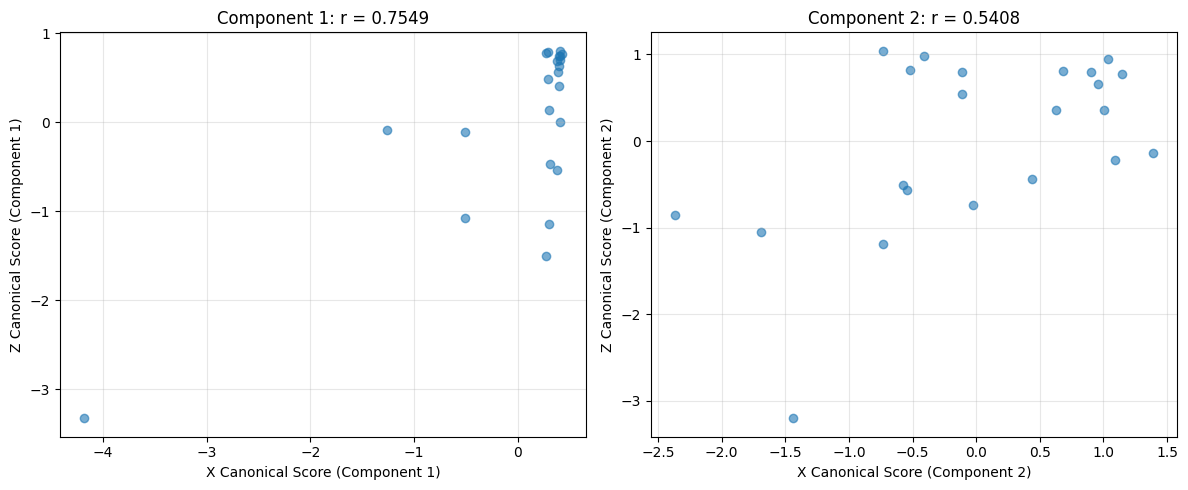


Permutation Test for Statistical Significance
Observed statistic (sum of squared correlations): 0.862311
Running 1000 permutations...
  Completed 100/1000 permutations...
  Completed 200/1000 permutations...
  Completed 300/1000 permutations...
  Completed 400/1000 permutations...
  Completed 500/1000 permutations...
  Completed 600/1000 permutations...
  Completed 700/1000 permutations...
  Completed 800/1000 permutations...
  Completed 900/1000 permutations...
  Completed 1000/1000 permutations...

Permutation p-value: 0.0200
95% percentile of permuted statistics: 0.773669
99% percentile of permuted statistics: 0.909176


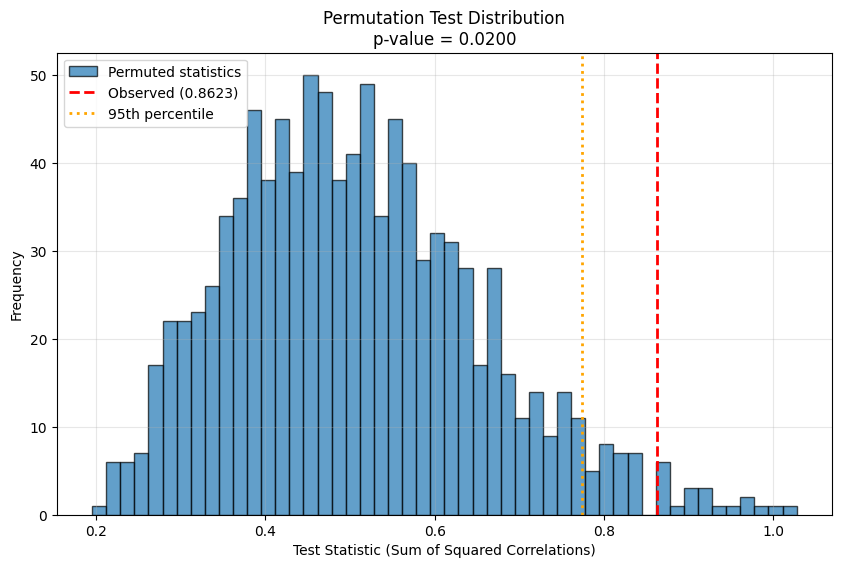

Correlations: [np.float64(0.7548584158858421), np.float64(0.5408327813081565)]
Permutation p-value: 0.01998001998001998


In [ ]:
# 간,신장,대사 vs PAN% 
X = df1[['AST', 'ALT', 'ALP', 'Bilirubin', 'Protein', 'Albumin', 
         'Cholesterol', 'R_Glucose', 'BUN', 'Cr', 'Amylase', 'CRP']] # 간,신장,대사
Z = df1[['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']] # PAN%

X_cols = ['AST', 'ALT', 'ALP', 'Bilirubin', 'Protein', 'Albumin', 
          'Cholesterol', 'R_Glucose', 'BUN', 'Cr', 'Amylase', 'CRP']
Z_cols = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']

results = apply_sparse_cca(X, Z, X_cols=X_cols, Z_cols=Z_cols)

print(f"Correlations: {results['correlations']}")
print(f"Permutation p-value: {results['permutation_pvalue']}")

Finding optimal number of components...
Component 1: correlation = 0.9614
Component 2: correlation = 0.9349
Component 3: correlation = 0.8209
Component 4: correlation = 0.6360
Component 5: correlation = 0.4276

Recommended n_components: 2

Grid search for best penalty parameters...
Best penaltyu: 0.300
Best penaltyv: 0.700
Best CV score: 0.3679

Applying Sparse CCA with best parameters...
penaltyu = 0.300, penaltyv = 0.700, n_components = 2
Sparse CCA Component 1: correlation = 0.6773
Sparse CCA Component 2: correlation = 0.6456

Average correlation: 0.6615

=== Component 1 ===

X Weights:
Protein       -0.999198
Albumin       -0.040032
AST           -0.000000
ALT            0.000000
Bilirubin     -0.000000
ALP           -0.000000
Cholesterol   -0.000000
R_Glucose      0.000000
BUN            0.000000
Cr            -0.000000
Amylase       -0.000000
CRP            0.000000
dtype: float64
Non-zero weights: 2 / 12

Z Weights:
Transitional B    -0.735135
ABC                0.662334
Plasma 

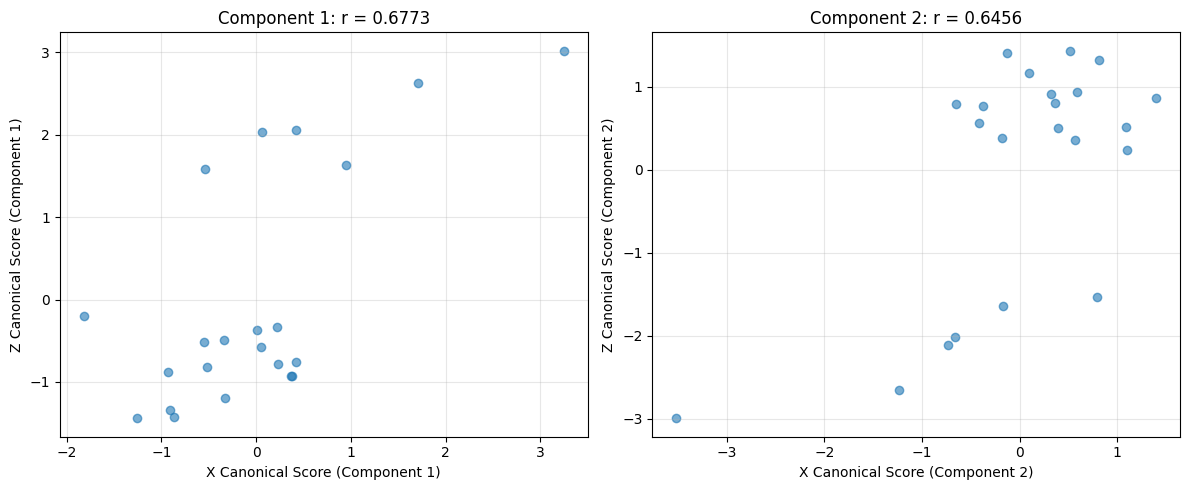


Permutation Test for Statistical Significance
Observed statistic (sum of squared correlations): 0.875543
Running 1000 permutations...
  Completed 100/1000 permutations...
  Completed 200/1000 permutations...
  Completed 300/1000 permutations...
  Completed 400/1000 permutations...
  Completed 500/1000 permutations...
  Completed 600/1000 permutations...
  Completed 700/1000 permutations...
  Completed 800/1000 permutations...
  Completed 900/1000 permutations...
  Completed 1000/1000 permutations...

Permutation p-value: 0.0500
95% percentile of permuted statistics: 0.866787
99% percentile of permuted statistics: 1.037545


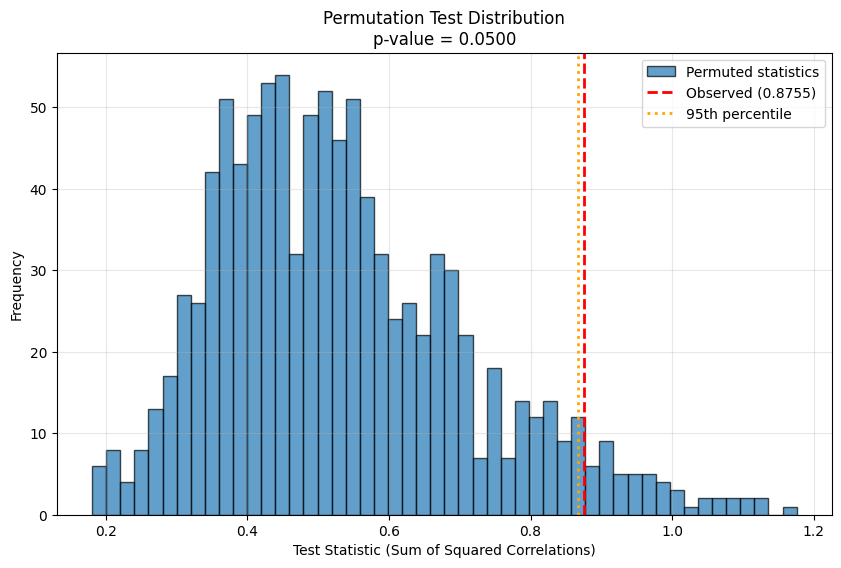

Correlations: [np.float64(0.677295913801745), np.float64(0.6456106481160697)]
Permutation p-value: 0.04995004995004995


In [ ]:
# 간,신장,대사 vs B소분류
X = df1[['AST', 'ALT', 'ALP', 'Bilirubin', 'Protein', 'Albumin', 
         'Cholesterol', 'R_Glucose', 'BUN', 'Cr', 'Amylase', 'CRP']] # 간,신장,대사
Z = df1[['Transitional B', 'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']] # B%

X_cols = ['AST', 'ALT', 'ALP', 'Bilirubin', 'Protein', 'Albumin', 
          'Cholesterol', 'R_Glucose', 'BUN', 'Cr', 'Amylase', 'CRP']
Z_cols = ['Transitional B', 'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']

results = apply_sparse_cca(X, Z, X_cols=X_cols, Z_cols=Z_cols)

print(f"Correlations: {results['correlations']}")
print(f"Permutation p-value: {results['permutation_pvalue']}")

Finding optimal number of components...
Component 1: correlation = 0.9852
Component 2: correlation = 0.9139

Recommended n_components: 2

Grid search for best penalty parameters...
Best penaltyu: 0.500
Best penaltyv: 0.700
Best CV score: 0.4893

Applying Sparse CCA with best parameters...
penaltyu = 0.500, penaltyv = 0.700, n_components = 2
Sparse CCA Component 1: correlation = 0.6469
Sparse CCA Component 2: correlation = 0.5467

Average correlation: 0.5968

=== Component 1 ===

X Weights:
ALT           -0.780612
AST           -0.588489
Protein        0.137330
Bilirubin     -0.115418
Albumin        0.110202
ALP            0.000000
Cholesterol    0.000000
R_Glucose     -0.000000
BUN           -0.000000
Cr            -0.000000
Amylase        0.000000
CRP           -0.000000
dtype: float64
Non-zero weights: 5 / 12

Z Weights:
gd1T      0.868644
ConvT%   -0.385913
gd2T      0.310691
NKT2      0.000000
MAIT      0.000000
dtype: float64
Non-zero weights: 3 / 5

=== Component 2 ===

X Weights

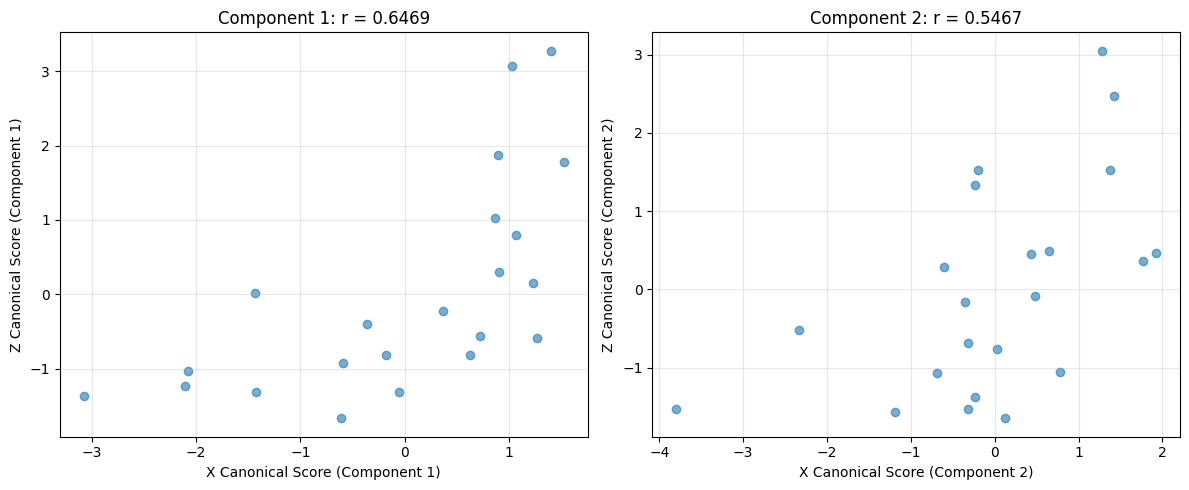


Permutation Test for Statistical Significance
Observed statistic (sum of squared correlations): 0.717335
Running 1000 permutations...
  Completed 100/1000 permutations...
  Completed 200/1000 permutations...
  Completed 300/1000 permutations...
  Completed 400/1000 permutations...
  Completed 500/1000 permutations...
  Completed 600/1000 permutations...
  Completed 700/1000 permutations...
  Completed 800/1000 permutations...
  Completed 900/1000 permutations...
  Completed 1000/1000 permutations...

Permutation p-value: 0.5295
95% percentile of permuted statistics: 0.995429
99% percentile of permuted statistics: 1.130135


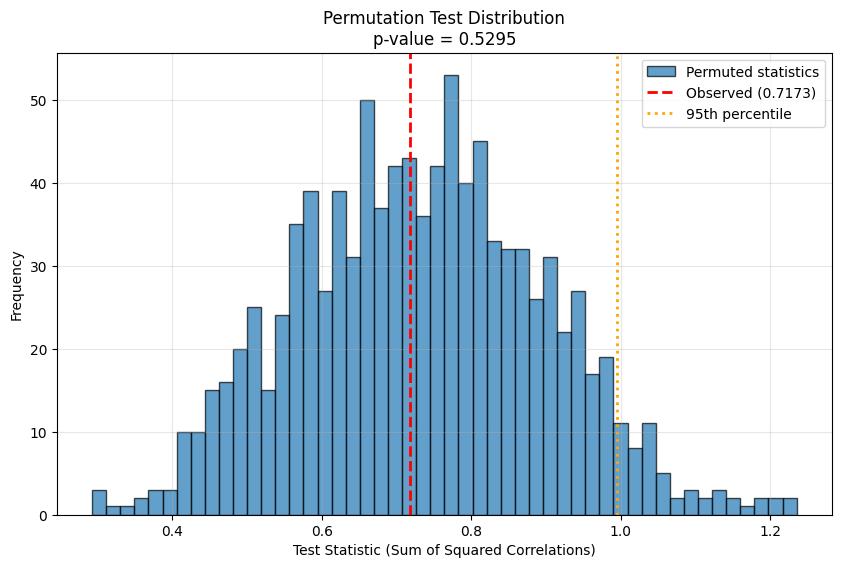

Correlations: [np.float64(0.6468768559865639), np.float64(0.5467044567386815)]
Permutation p-value: 0.5294705294705294


In [ ]:
# 간,신장,대사 vs T세포
X = df1[['AST', 'ALT', 'ALP', 'Bilirubin', 'Protein', 'Albumin', 
         'Cholesterol', 'R_Glucose', 'BUN', 'Cr', 'Amylase', 'CRP']]
Z = df1[['NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%']]

X_cols = ['AST', 'ALT', 'ALP', 'Bilirubin', 'Protein', 'Albumin', 
          'Cholesterol', 'R_Glucose', 'BUN', 'Cr', 'Amylase', 'CRP']
Z_cols = ['NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%']

results = apply_sparse_cca(X, Z, X_cols=X_cols, Z_cols=Z_cols)

print(f"Correlations: {results['correlations']}")
print(f"Permutation p-value: {results['permutation_pvalue']}")

In [142]:
df.columns

Index(['ID', 'Sex', 'Age', 'BMI', 'AST', 'ALT', 'ALP', 'Bilirubin', 'Protein',
       'Albumin', 'PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL', 'R_Glucose',
       'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl', 'Amylase',
       'CRP', 'B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T', 'NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T',
       'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Transitional B',
       'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC', 'Total', 'B.1',
       'CD11b.1', 'HLADR.1', 'NK.1', 'NKT1.1', 'T.1', 'Transitional B.1',
       'Memory B.1', 'Early Plasma B .1', 'Plasma B.1', 'ABC.1'],
      dtype='object')

Finding optimal number of components...
Component 1: correlation = 0.9546
Component 2: correlation = 0.8513

Recommended n_components: 1

Grid search for best penalty parameters...
Best penaltyu: 0.300
Best penaltyv: 0.100
Best CV score: 0.4101

Applying Sparse CCA with best parameters...
penaltyu = 0.300, penaltyv = 0.100, n_components = 1
Sparse CCA Component 1: correlation = 0.4378

Average correlation: 0.4378

=== Component 1 ===

X Weights:
AST           -0.999198
ALT           -0.040031
ALP           -0.000000
Bilirubin     -0.000000
Protein       -0.000000
Albumin        0.000000
Cholesterol   -0.000000
R_Glucose      0.000000
BUN           -0.000000
Cr            -0.000000
Amylase       -0.000000
CRP           -0.000000
dtype: float64
Non-zero weights: 2 / 12

Z Weights:
CD4+Treg    1.0
CD8+T      -0.0
CD4+T       0.0
CD8+Treg    0.0
dtype: float64
Non-zero weights: 1 / 4



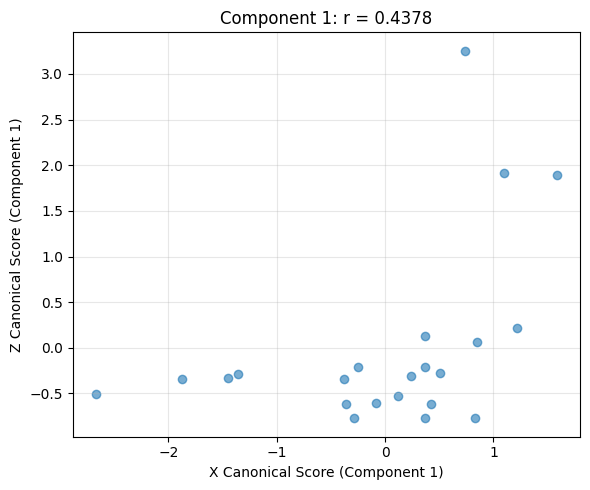


Permutation Test for Statistical Significance
Observed statistic (sum of squared correlations): 0.191692
Running 1000 permutations...
  Completed 100/1000 permutations...
  Completed 200/1000 permutations...
  Completed 300/1000 permutations...
  Completed 400/1000 permutations...
  Completed 500/1000 permutations...
  Completed 600/1000 permutations...
  Completed 700/1000 permutations...
  Completed 800/1000 permutations...
  Completed 900/1000 permutations...
  Completed 1000/1000 permutations...

Permutation p-value: 0.7283
95% percentile of permuted statistics: 0.457714
99% percentile of permuted statistics: 0.521517


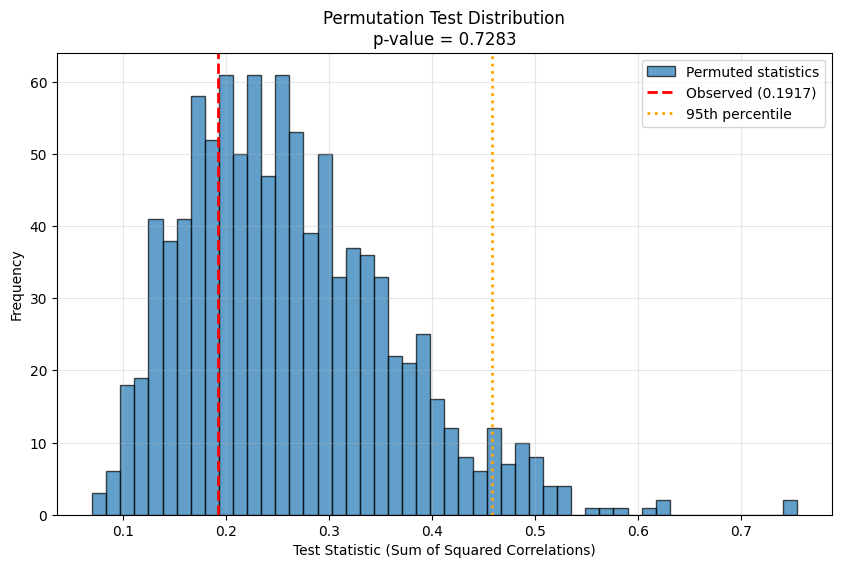

Correlations: [np.float64(0.4378265368050255)]
Permutation p-value: 0.7282717282717283


In [143]:
# 간,신장,대사 vs ConvT
X = df1[['AST', 'ALT', 'ALP', 'Bilirubin', 'Protein', 'Albumin', 
         'Cholesterol', 'R_Glucose', 'BUN', 'Cr', 'Amylase', 'CRP']]
Z = df1[['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg']]

X_cols = ['AST', 'ALT', 'ALP', 'Bilirubin', 'Protein', 'Albumin', 
          'Cholesterol', 'R_Glucose', 'BUN', 'Cr', 'Amylase', 'CRP']
Z_cols = ['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg']

results = apply_sparse_cca(X, Z, X_cols=X_cols, Z_cols=Z_cols)

print(f"Correlations: {results['correlations']}")
print(f"Permutation p-value: {results['permutation_pvalue']}")

Finding optimal number of components...
Component 1: correlation = 1.0000
Component 2: correlation = 0.9875

Recommended n_components: 2

Grid search for best penalty parameters...
Best penaltyu: 0.900
Best penaltyv: 0.600
Best CV score: -0.0185

Applying Sparse CCA with best parameters...
penaltyu = 0.900, penaltyv = 0.600, n_components = 2
Sparse CCA Component 1: correlation = 0.7217
Sparse CCA Component 2: correlation = 0.6255

Average correlation: 0.6736

=== Component 1 ===

X Weights:
CRP           -0.445539
Albumin        0.429236
Protein        0.388481
Cr             0.379094
ALT           -0.328290
ALP           -0.291318
Cholesterol   -0.195282
Bilirubin     -0.184223
Amylase        0.164048
R_Glucose      0.158931
AST            0.067247
BUN            0.034860
dtype: float64
Non-zero weights: 12 / 12

Z Weights:
GD1TgrzK   -0.804732
CD8grzk    -0.452097
CD8trm     -0.352878
GD2Ttrm    -0.100187
CD4trm     -0.081184
MAITgrzK   -0.077789
GD2TgrzK   -0.028499
CD4grzk    -0.00

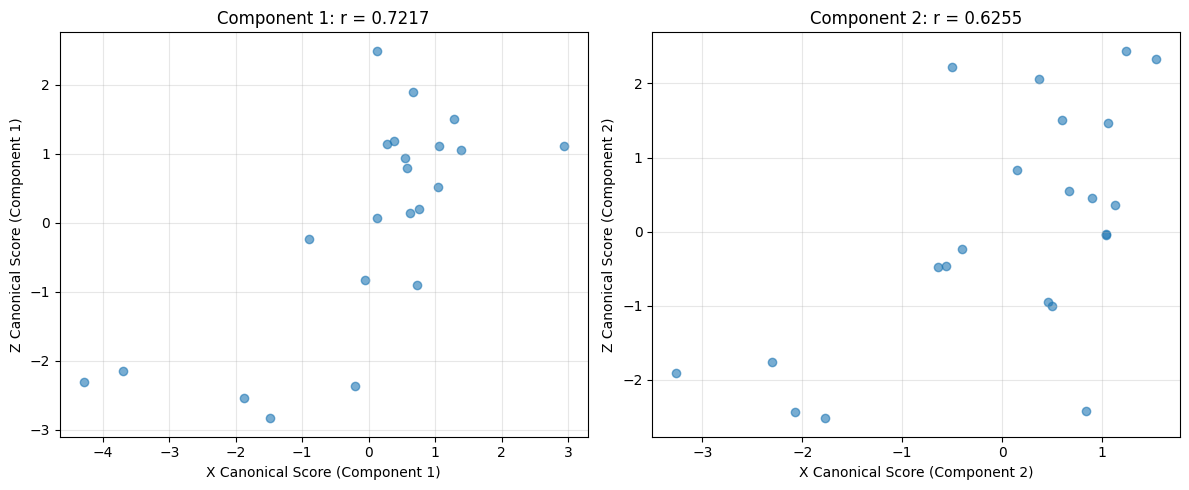


Permutation Test for Statistical Significance
Observed statistic (sum of squared correlations): 0.912200
Running 1000 permutations...
  Completed 100/1000 permutations...
  Completed 200/1000 permutations...
  Completed 300/1000 permutations...
  Completed 400/1000 permutations...
  Completed 500/1000 permutations...
  Completed 600/1000 permutations...
  Completed 700/1000 permutations...
  Completed 800/1000 permutations...
  Completed 900/1000 permutations...
  Completed 1000/1000 permutations...

Permutation p-value: 0.3786
95% percentile of permuted statistics: 1.140429
99% percentile of permuted statistics: 1.280841


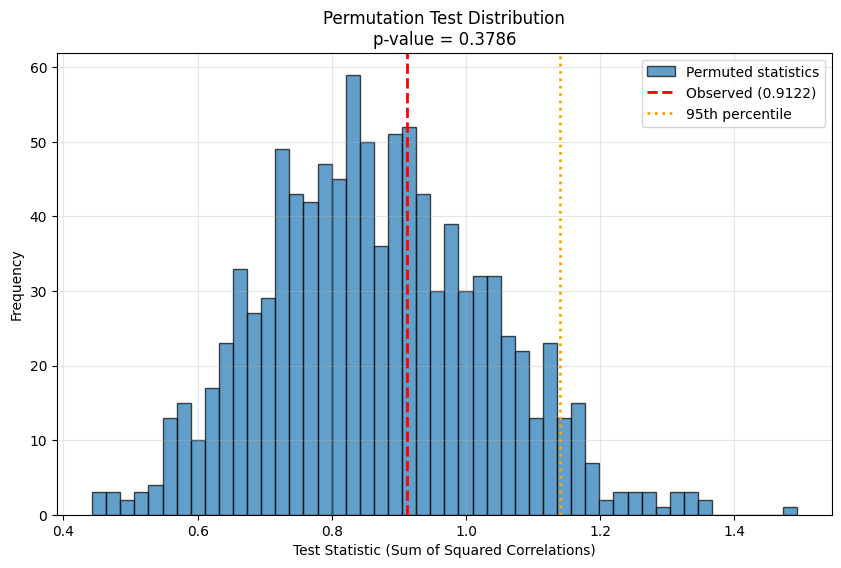

Correlations: [np.float64(0.7217329236822543), np.float64(0.6255413834254104)]
Permutation p-value: 0.3786213786213786


In [141]:
# 간,신장,대사 vs Tsubset
X = df1[['AST', 'ALT', 'ALP', 'Bilirubin', 'Protein', 'Albumin', 
         'Cholesterol', 'R_Glucose', 'BUN', 'Cr', 'Amylase', 'CRP']]
Z = df1[[  'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK']]

X_cols = ['AST', 'ALT', 'ALP', 'Bilirubin', 'Protein', 'Albumin', 
          'Cholesterol', 'R_Glucose', 'BUN', 'Cr', 'Amylase', 'CRP']
Z_cols = [  'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK']

results = apply_sparse_cca(X, Z, X_cols=X_cols, Z_cols=Z_cols)

print(f"Correlations: {results['correlations']}")
print(f"Permutation p-value: {results['permutation_pvalue']}")

## df2

### CCA 분석

In [91]:
# 간 vs 전체 면역세포
X_cols = ['AST', 'ALT', 'ALP', 'Bilirubin', 'Albumin','PT', 'APTT']
Z_cols = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T', 'NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T',
       'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Transitional B',
       'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']

res = run_cca_perm(
    df=df2,
    X_cols=X_cols,
    Z_cols=Z_cols,
    n_components=2,
    standardize=True,
    B=1000,
    random_state=0,
    abs_test=True,
    plus_one_correction=True,
    verbose=True
)


=== CCA + Permutation Test ===
n_components = 2
Observed correlation (comp1): 1.000000
Permutation p-value: 0.652348  (B=1000, abs_test=True)

[X weights]
PT           0.521438
ALP          0.441111
AST          0.399009
APTT         0.357457
Albumin     -0.322637
Bilirubin   -0.281527
ALT         -0.251372
dtype: float64

[Z weights]
CD4+Treg           0.558734
MAITtrm            0.426288
CD20T              0.318947
T                  0.256605
CD4trm             0.214811
CD8grzk           -0.194728
Early Plasma B     0.178003
Memory B           0.166330
CD4+T              0.162667
ABC                0.150119
gd1T               0.134615
B                  0.133110
CD8trm            -0.122519
Plasma B          -0.117171
ConvT%            -0.105916
NK                 0.099675
CD11b              0.093918
NKT2               0.093717
CD4grzk           -0.085825
GD1Ttrm            0.080713
gd2T               0.079983
MAITgrzK           0.075416
GD2TgrzK           0.069887
GD1TgrzK          

In [92]:
# 대사 vs 전체 면역세포
X_cols = ['TG', 'LDL', 'HDL',
'F_Glucose', 'HbA1c']
Z_cols = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T', 'NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T',
       'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Transitional B',
       'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']

res = run_cca_perm(
    df=df2,
    X_cols=X_cols,
    Z_cols=Z_cols,
    n_components=2,
    standardize=True,
    B=1000,
    random_state=0,
    abs_test=True,
    plus_one_correction=True,
    verbose=True
)


=== CCA + Permutation Test ===
n_components = 2
Observed correlation (comp1): 1.000000
Permutation p-value: 0.655345  (B=1000, abs_test=True)

[X weights]
HDL          0.861018
LDL          0.351379
F_Glucose    0.264825
TG           0.247218
HbA1c        0.062710
dtype: float64

[Z weights]
Early Plasma B     0.350602
CD20T             -0.334063
B                 -0.305810
MAIT               0.302916
GD2Ttrm           -0.290140
ABC               -0.273146
HLADR             -0.261260
GD2TgrzK           0.259477
gd1T              -0.226214
CD8grzk            0.182020
CD8+Treg          -0.163995
GD1Ttrm           -0.161798
MAITtrm           -0.155649
CD11b              0.142590
GD1TgrzK           0.133862
Memory B          -0.131251
Plasma B          -0.123522
NKT2              -0.121355
T                  0.104383
CD4trm             0.099472
CD8trm             0.075691
ConvT%             0.057739
CD8+T             -0.052277
CD4+T             -0.043585
NKT1               0.035144
Transi

In [93]:
# 신장 vs 전체 면역세포
X_cols = ['BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl']
Z_cols = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T', 'NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T',
       'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Transitional B',
       'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']

res = run_cca_perm(
    df=df2,
    X_cols=X_cols,
    Z_cols=Z_cols,
    n_components=2,
    standardize=True,
    B=1000,
    random_state=0,
    abs_test=True,
    plus_one_correction=True,
    verbose=True
)


=== CCA + Permutation Test ===
n_components = 2
Observed correlation (comp1): 1.000000
Permutation p-value: 0.673327  (B=1000, abs_test=True)

[X weights]
Cr              0.713527
GFR(CKD_EPI)   -0.670759
BUN            -0.179792
CrCl            0.092937
dtype: float64

[Z weights]
CD4grzk           -0.428791
B                  0.380666
gd1T               0.360823
NKT1              -0.285465
MAITgrzK           0.251553
CD20T              0.220639
CD11b             -0.219129
MAITtrm            0.211307
GD2TgrzK          -0.199113
Early Plasma B    -0.195931
CD8+Treg           0.192050
CD4+T              0.143044
CD4+Treg          -0.132323
CD8grzk           -0.131566
GD1TgrzK          -0.118610
CD4trm             0.107393
Plasma B           0.105377
Memory B           0.097699
GD2Ttrm            0.093751
ConvT%            -0.085299
T                  0.072747
GD1Ttrm            0.069698
NKT2               0.058346
ABC               -0.052970
MAIT               0.044186
CD8trm          

### SCCA 분석

Finding optimal number of components...
Component 1: correlation = 1.0000
Component 2: correlation = 0.9778

Recommended n_components: 2

Grid search for best penalty parameters...
Best penaltyu: 0.300
Best penaltyv: 0.100
Best CV score: 0.1574

Applying Sparse CCA with best parameters...
penaltyu = 0.300, penaltyv = 0.100, n_components = 2
Sparse CCA Component 1: correlation = 0.4612
Sparse CCA Component 2: correlation = 0.5190

Average correlation: 0.4901

=== Component 1 ===

X Weights:
APTT           -0.961249
GFR(CKD_EPI)   -0.275683
AST             0.000000
Bilirubin       0.000000
ALT            -0.000000
Albumin         0.000000
PT              0.000000
Cholesterol    -0.000000
ALP            -0.000000
TG              0.000000
LDL            -0.000000
F_Glucose      -0.000000
HDL            -0.000000
HbA1c           0.000000
BUN             0.000000
Cr              0.000000
CrCl            0.000000
dtype: float64
Non-zero weights: 2 / 17

Z Weights:
CD11b   -1.0
B        0.0
HL

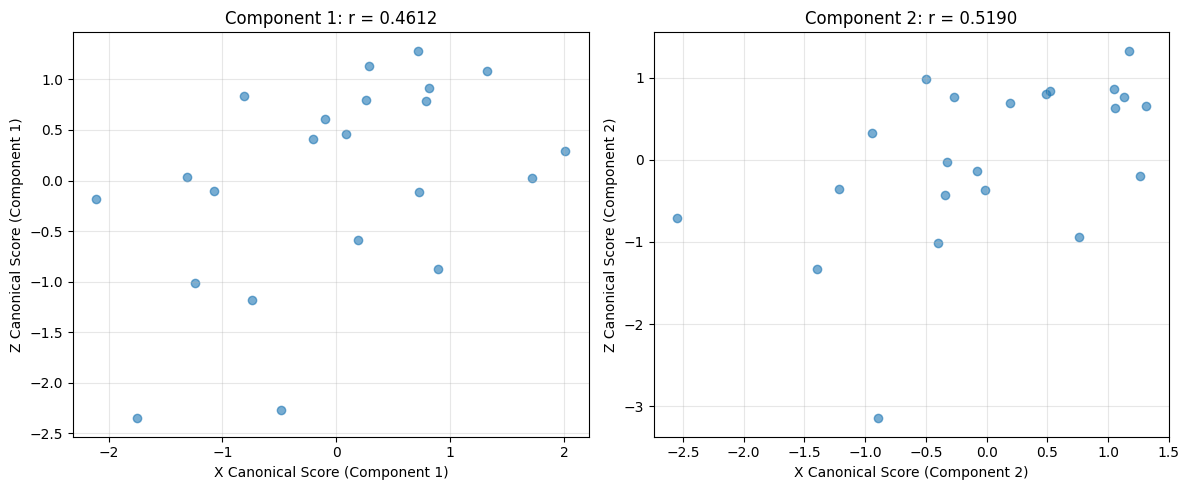


Permutation Test for Statistical Significance
Observed statistic (sum of squared correlations): 0.482080
Running 1000 permutations...
  Completed 100/1000 permutations...
  Completed 200/1000 permutations...
  Completed 300/1000 permutations...
  Completed 400/1000 permutations...
  Completed 500/1000 permutations...
  Completed 600/1000 permutations...
  Completed 700/1000 permutations...
  Completed 800/1000 permutations...
  Completed 900/1000 permutations...
  Completed 1000/1000 permutations...

Permutation p-value: 0.8631
95% percentile of permuted statistics: 0.870565
99% percentile of permuted statistics: 0.981388


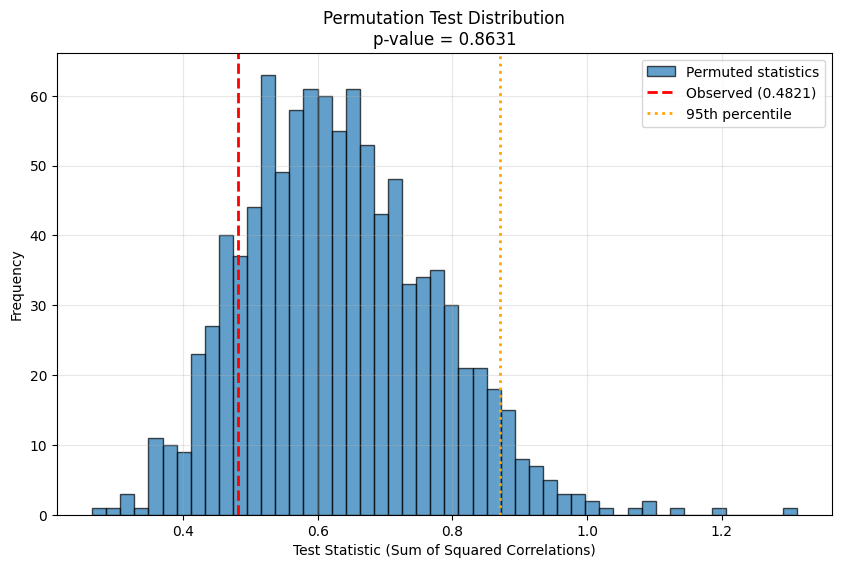

Correlations: [np.float64(0.461174122146177), np.float64(0.5190361535355905)]
Permutation p-value: 0.8631368631368631


In [20]:
# 간,신장,대사 vs PAN% 
X_cols = ['AST', 'ALT', 'ALP', 'Bilirubin', 
 'Albumin','PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL',
'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl']
Z_cols = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']

X = df2[X_cols]
Z = df2[Z_cols]

results = apply_sparse_cca(X, Z, X_cols=X_cols, Z_cols=Z_cols)

print(f"Correlations: {results['correlations']}")
print(f"Permutation p-value: {results['permutation_pvalue']}")

Finding optimal number of components...
Component 1: correlation = 0.9927
Component 2: correlation = 0.9692

Recommended n_components: 2

Grid search for best penalty parameters...
Best penaltyu: 0.500
Best penaltyv: 0.100
Best CV score: 0.4101

Applying Sparse CCA with best parameters...
penaltyu = 0.500, penaltyv = 0.100, n_components = 2
Sparse CCA Component 1: correlation = 0.6894
Sparse CCA Component 2: correlation = 0.6066

Average correlation: 0.6480

=== Component 1 ===

X Weights:
ALP             0.647725
F_Glucose       0.639442
HbA1c           0.299726
Cholesterol     0.201223
CrCl            0.180627
PT             -0.092810
AST            -0.000000
Albumin        -0.000000
ALT             0.000000
TG              0.000000
APTT            0.000000
Bilirubin      -0.000000
HDL            -0.000000
LDL             0.000000
BUN            -0.000000
Cr             -0.000000
GFR(CKD_EPI)    0.000000
dtype: float64
Non-zero weights: 6 / 17

Z Weights:
MAIT      1.0
NKT2      0.0


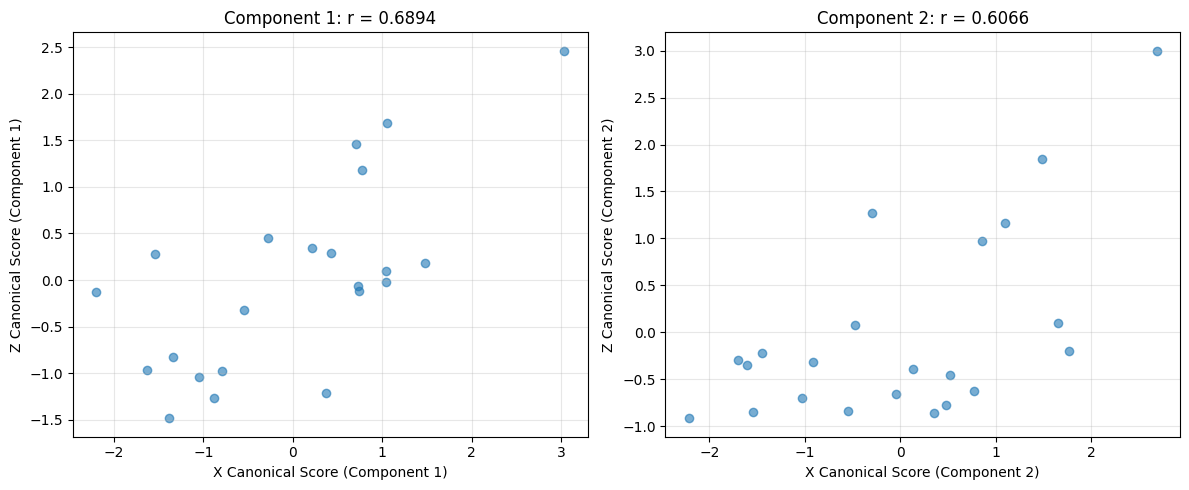


Permutation Test for Statistical Significance
Observed statistic (sum of squared correlations): 0.843291
Running 1000 permutations...
  Completed 100/1000 permutations...
  Completed 200/1000 permutations...
  Completed 300/1000 permutations...
  Completed 400/1000 permutations...
  Completed 500/1000 permutations...
  Completed 600/1000 permutations...
  Completed 700/1000 permutations...
  Completed 800/1000 permutations...
  Completed 900/1000 permutations...
  Completed 1000/1000 permutations...

Permutation p-value: 0.4575
95% percentile of permuted statistics: 1.100111
99% percentile of permuted statistics: 1.234204


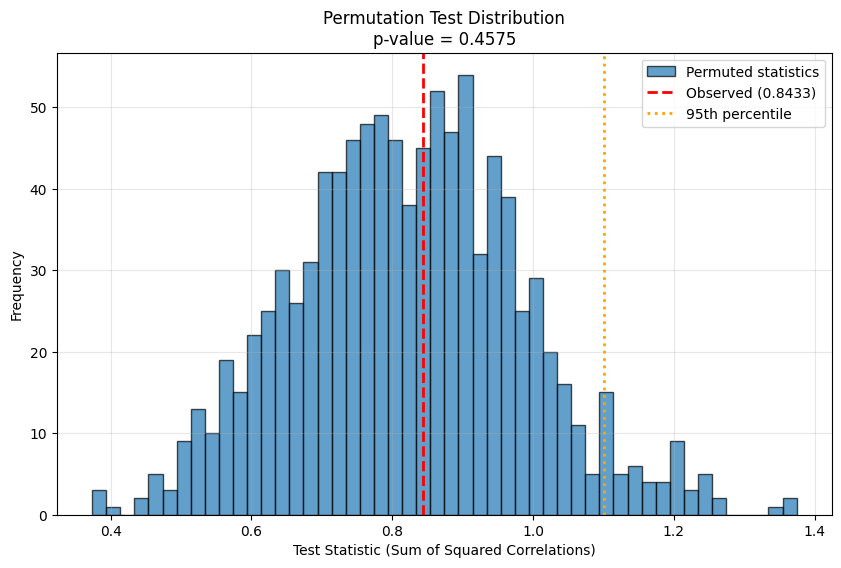

Correlations: [np.float64(0.6894093789299215), np.float64(0.6066346613653054)]
Permutation p-value: 0.45754245754245754


In [38]:
# 간,신장,대사 vs T% 
X_cols = ['AST', 'ALT', 'ALP', 'Bilirubin', 
 'Albumin','PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL',
'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl']
Z_cols = ['NKT2', 'MAIT', 'gd1T','gd2T', 'ConvT%']

X = df2[X_cols]
Z = df2[Z_cols]

results = apply_sparse_cca(X, Z, X_cols=X_cols, Z_cols=Z_cols)

print(f"Correlations: {results['correlations']}")
print(f"Permutation p-value: {results['permutation_pvalue']}")

Finding optimal number of components...
Component 1: correlation = 0.9794
Component 2: correlation = 0.9149

Recommended n_components: 2

Grid search for best penalty parameters...
Best penaltyu: 0.300
Best penaltyv: 0.800
Best CV score: 0.1765

Applying Sparse CCA with best parameters...
penaltyu = 0.300, penaltyv = 0.800, n_components = 2
Sparse CCA Component 1: correlation = 0.5949
Sparse CCA Component 2: correlation = 0.4302

Average correlation: 0.5126

=== Component 1 ===

X Weights:
APTT           -0.961249
ALT            -0.275683
AST            -0.000000
Bilirubin       0.000000
ALP            -0.000000
Albumin         0.000000
PT              0.000000
Cholesterol    -0.000000
TG              0.000000
LDL            -0.000000
HDL            -0.000000
F_Glucose      -0.000000
HbA1c           0.000000
BUN            -0.000000
Cr              0.000000
GFR(CKD_EPI)   -0.000000
CrCl            0.000000
dtype: float64
Non-zero weights: 2 / 17

Z Weights:
CD4+Treg   -0.772549
CD8+Tre

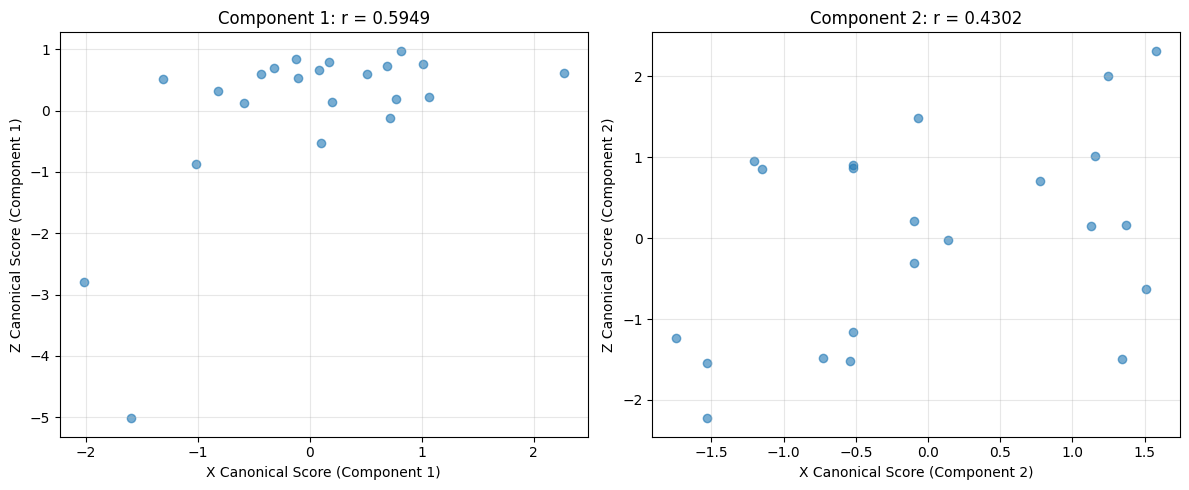


Permutation Test for Statistical Significance
Observed statistic (sum of squared correlations): 0.538988
Running 1000 permutations...
  Completed 100/1000 permutations...
  Completed 200/1000 permutations...
  Completed 300/1000 permutations...
  Completed 400/1000 permutations...
  Completed 500/1000 permutations...
  Completed 600/1000 permutations...
  Completed 700/1000 permutations...
  Completed 800/1000 permutations...
  Completed 900/1000 permutations...
  Completed 1000/1000 permutations...

Permutation p-value: 0.5495
95% percentile of permuted statistics: 0.806382
99% percentile of permuted statistics: 0.939917


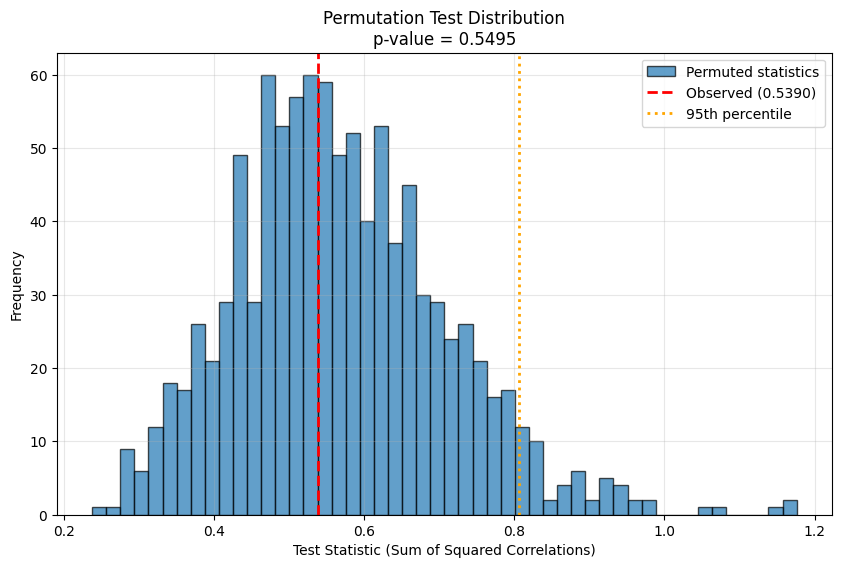

Correlations: [np.float64(0.5949102466826942), np.float64(0.43019696828180004)]
Permutation p-value: 0.5494505494505495


In [39]:
# 간,신장,대사 vs ConvT% 
X_cols = ['AST', 'ALT', 'ALP', 'Bilirubin', 
 'Albumin','PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL',
'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl']
Z_cols = ['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg']

X = df2[X_cols]
Z = df2[Z_cols]

results = apply_sparse_cca(X, Z, X_cols=X_cols, Z_cols=Z_cols)

print(f"Correlations: {results['correlations']}")
print(f"Permutation p-value: {results['permutation_pvalue']}")

Finding optimal number of components...
Component 1: correlation = 1.0000
Component 2: correlation = 0.8843

Recommended n_components: 1

Grid search for best penalty parameters...
Best penaltyu: 0.700
Best penaltyv: 0.600
Best CV score: 0.1494

Applying Sparse CCA with best parameters...
penaltyu = 0.700, penaltyv = 0.600, n_components = 1
Sparse CCA Component 1: correlation = 0.6827

Average correlation: 0.6827

=== Component 1 ===

X Weights:
PT             -0.550565
CrCl           -0.382481
APTT            0.369917
TG             -0.340986
HDL             0.331765
Bilirubin      -0.306570
GFR(CKD_EPI)    0.203206
ALP             0.148588
F_Glucose      -0.136758
HbA1c          -0.106134
AST            -0.009204
ALT            -0.000000
Albumin        -0.000000
Cholesterol    -0.000000
LDL             0.000000
Cr              0.000000
BUN             0.000000
dtype: float64
Non-zero weights: 11 / 17

Z Weights:
MAITtrm    -0.663505
MAITgrzK    0.563673
CD4trm     -0.428522
CD8trm   

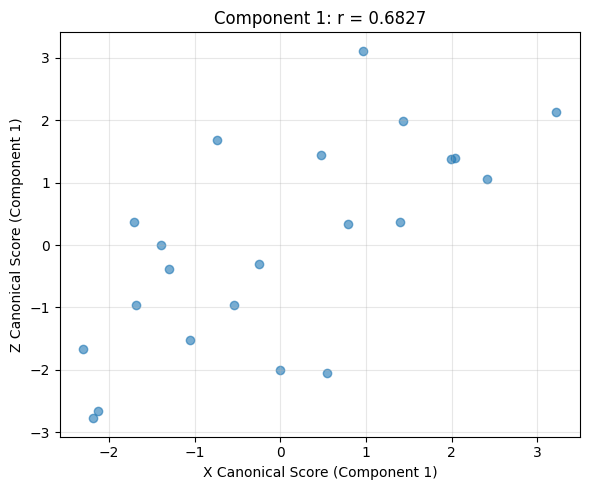


Permutation Test for Statistical Significance
Observed statistic (sum of squared correlations): 0.466135
Running 1000 permutations...
  Completed 100/1000 permutations...
  Completed 200/1000 permutations...
  Completed 300/1000 permutations...
  Completed 400/1000 permutations...
  Completed 500/1000 permutations...
  Completed 600/1000 permutations...
  Completed 700/1000 permutations...
  Completed 800/1000 permutations...
  Completed 900/1000 permutations...
  Completed 1000/1000 permutations...

Permutation p-value: 0.7493
95% percentile of permuted statistics: 0.686016
99% percentile of permuted statistics: 0.750406


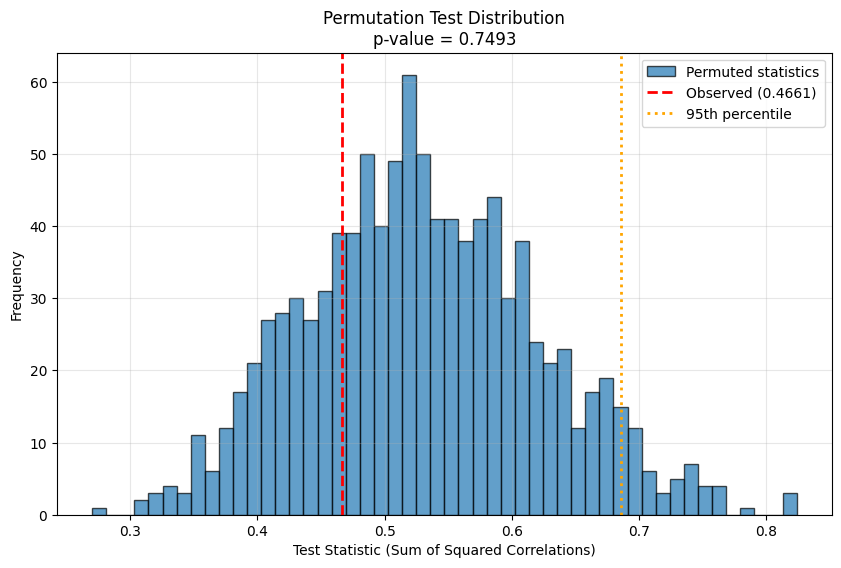

Correlations: [np.float64(0.6827407737286334)]
Permutation p-value: 0.7492507492507493


In [41]:
# 간,신장,대사 vs Tsubset% 
X_cols = ['AST', 'ALT', 'ALP', 'Bilirubin', 
 'Albumin','PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL',
'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl']
Z_cols = [  'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK']

X = df2[X_cols]
Z = df2[Z_cols]

results = apply_sparse_cca(X, Z, X_cols=X_cols, Z_cols=Z_cols)

print(f"Correlations: {results['correlations']}")
print(f"Permutation p-value: {results['permutation_pvalue']}")

Finding optimal number of components...
Component 1: correlation = 0.9996
Component 2: correlation = 0.9950

Recommended n_components: 2

Grid search for best penalty parameters...
Best penaltyu: 0.600
Best penaltyv: 0.100
Best CV score: 0.4244

Applying Sparse CCA with best parameters...
penaltyu = 0.600, penaltyv = 0.100, n_components = 2
Sparse CCA Component 1: correlation = 0.5471
Sparse CCA Component 2: correlation = 0.6155

Average correlation: 0.5813

=== Component 1 ===

X Weights:
Cr              0.641253
BUN             0.545578
TG              0.278364
ALP            -0.273610
Albumin         0.250450
LDL            -0.246112
HbA1c          -0.086210
PT             -0.069934
GFR(CKD_EPI)   -0.039904
Bilirubin       0.039628
F_Glucose       0.002820
AST            -0.000000
ALT            -0.000000
Cholesterol    -0.000000
APTT            0.000000
HDL            -0.000000
CrCl            0.000000
dtype: float64
Non-zero weights: 11 / 17

Z Weights:
Transitional B     1.0
Memo

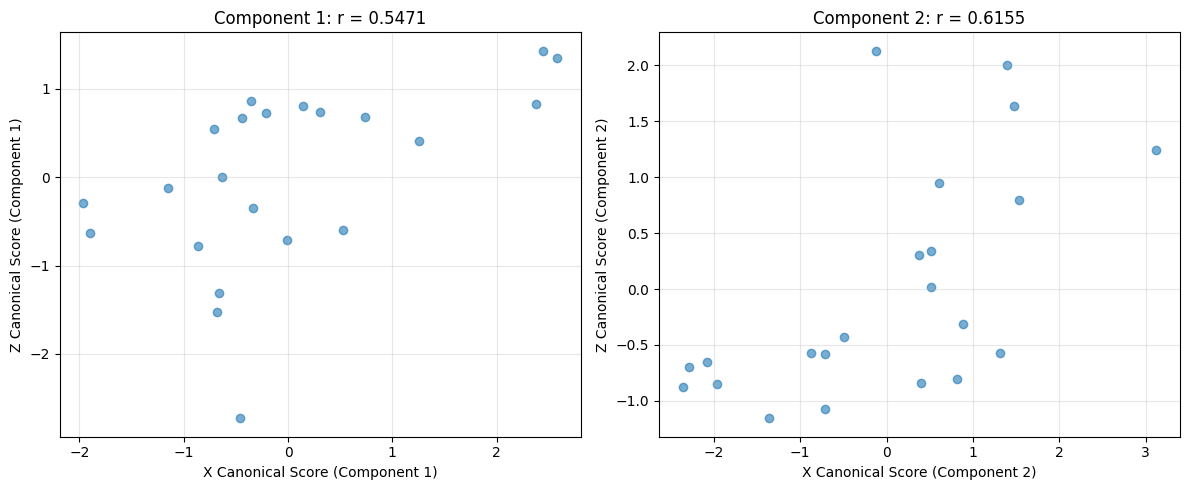


Permutation Test for Statistical Significance
Observed statistic (sum of squared correlations): 0.678169
Running 1000 permutations...
  Completed 100/1000 permutations...
  Completed 200/1000 permutations...
  Completed 300/1000 permutations...
  Completed 400/1000 permutations...
  Completed 500/1000 permutations...
  Completed 600/1000 permutations...
  Completed 700/1000 permutations...
  Completed 800/1000 permutations...
  Completed 900/1000 permutations...
  Completed 1000/1000 permutations...

Permutation p-value: 0.8791
95% percentile of permuted statistics: 1.115058
99% percentile of permuted statistics: 1.232439


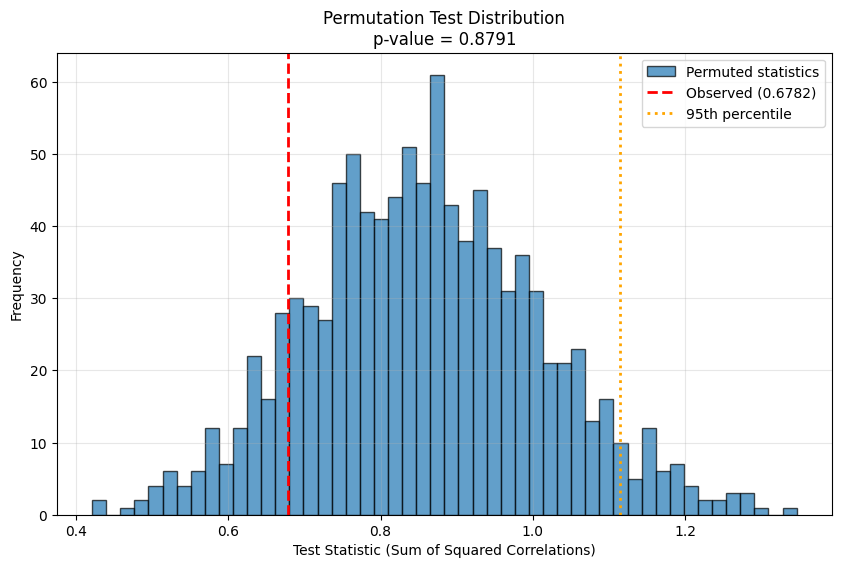

Correlations: [np.float64(0.5470741637547137), np.float64(0.6155317561612905)]
Permutation p-value: 0.8791208791208791


In [40]:
# 간,신장,대사 vs B% 
X_cols = ['AST', 'ALT', 'ALP', 'Bilirubin', 
 'Albumin','PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL',
'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl']
Z_cols = ['Transitional B', 'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC']

X = df2[X_cols]
Z = df2[Z_cols]

results = apply_sparse_cca(X, Z, X_cols=X_cols, Z_cols=Z_cols)

print(f"Correlations: {results['correlations']}")
print(f"Permutation p-value: {results['permutation_pvalue']}")

### 0123 미팅 이후 수정

Task1- plsr, partial correlation
1. 결측치를 삭제하고 partial correlation, plsr
2. sparse plsr
3. plsr 할 때 그룹을 지어서
4. 통제변수에 다른 피검사를 넣어보라는데.. 뭘 넣어야될지.. 

In [25]:
pip install sparse-pls

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [10]:
from sparse_pls.model import SparsePLS
from sklearn.model_selection import train_test_split

In [11]:
path = 'C:/Users/nva_kist/Desktop/minsun/KIST/BioMarker/refined_dataset.xlsx'
df = pd.read_excel(path)

In [12]:
cols = ['B',	'CD11b','HLADR','NK','NKT1','T',
        'NKT2',	'MAIT'	,'gd1T','gd2T',	'ConvT%',
'CD8+T','CD4+T','CD8+Treg','CD4+Treg','CD20T','CD4trm','CD8trm','MAITtrm','GD1Ttrm',	
'GD2Ttrm','CD4grzk', 'CD8grzk','MAITgrzK','GD1TgrzK','GD2TgrzK','Transitional B',
'Memory B','Early Plasma B ','Plasma B','ABC'
]

# % 제거하기
df[cols] = (df[cols]
            .replace(r'^\s*$', pd.NA, regex=True) 
            .replace({',': ''}, regex=True)
            .replace({'%': ''}, regex=True)   
            .apply(pd.to_numeric, errors='coerce')
            *100)      

# unnamed 인 column 제거 
df = df.loc[:, ~df.columns.str.contains(r'^Unnamed')]

In [17]:
df.columns

Index(['ID', 'Sex', 'Age', 'BMI', 'AST', 'ALT', 'ALP', 'Bilirubin', 'Protein',
       'Albumin', 'PT', 'APTT', 'Cholesterol', 'TG', 'LDL', 'HDL', 'R_Glucose',
       'F_Glucose', 'HbA1c', 'BUN', 'Cr', 'GFR(CKD_EPI)', 'CrCl', 'Amylase',
       'CRP', 'B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T', 'NKT2', 'MAIT', 'gd1T',
       'gd2T', 'ConvT%', 'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'CD20T',
       'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm', 'CD4grzk',
       'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Transitional B',
       'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC', 'Total', 'B.1',
       'CD11b.1', 'HLADR.1', 'NK.1', 'NKT1.1', 'T.1', 'Transitional B.1',
       'Memory B.1', 'Early Plasma B .1', 'Plasma B.1', 'ABC.1'],
      dtype='object')

In [ ]:
# X: PAN% 6개 변수, y: Age
X = df[['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']]
y = df['Age']

model = SparsePLS(n_components=1, alpha=0.01, l1_ratio=0.5)
model.fit(X ,y)

In [ ]:
# df_del + BMI
columns = ['NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_mice, x='Age', y= c , covar=['BMI'], method='pearson'))
   print("_________________________________________________")